# Robustness of Graph Neural Networks at Scale - Quick Start

This notebook can be run in google colab and serves as a quick introduction to the [Robustness of Graph Neural Networks at Scale](https://github.com/sigeisler/robustness_of_gnns_at_scale) repository.

## 0. Setup

First, let's get the code and install requirements.


In [1]:
from networkx.convert import to_networkx_graph
from torch_geometric.utils import to_networkx

import AttackerGNN.MainAttack
import config
%cd {config.PROJECT_DIR}

E:\Masterarbeit\AttackerGNN


E:\Anaconda\envs\Masterarbeit\Lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
DATASET = 'cora_ml'

In [3]:
import os
files = ["cache/demo.json", "cache/demo/demo_1.pt", "cache/evasion_global_adj.json", "cache/evasion_global_attr.json", "cache/evasion_global_adj/evasion_global_adj_1.pt", "cache/evasion_global_attr/evasion_global_attr_1.pt"]

for file_path in files:
    if os.path.exists(file_path):
        os.remove(file_path)
        print(f"{file_path} has been deleted.")
    else:
        print(f"{file_path} does not exist.")

cache/demo.json has been deleted.
cache/demo/demo_1.pt has been deleted.
cache/evasion_global_adj.json does not exist.
cache/evasion_global_attr.json does not exist.
cache/evasion_global_adj/evasion_global_adj_1.pt does not exist.
cache/evasion_global_attr/evasion_global_attr_1.pt does not exist.


### Imports

In [4]:
SEED = 1

In [5]:
#7 run
#%cd robustness_of_gnns_at_scale
from matplotlib import pyplot as plt

from experiments import (
    experiment_train,
    experiment_local_attack_direct,
    experiment_global_attack_direct
)

%matplotlib inline

%load_ext autoreload
%autoreload 2

Use from seml.experiment import setup_logger instead.
Note that seml.experiment.Experiment already includes the logger setup.
See https://github.com/TUM-DAML/seml/blob/master/examples/example_experiment.py


[05/10/26 11:47:45] WARNING  Importing setup_logger directly from seml is deprecated.                ]8;id=431738;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\seml\__init__.py\__init__.py]8;;\:]8;id=115121;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\seml\__init__.py#10\10]8;;\
                             Use from seml.experiment import setup_logger instead.                                 
                             Note that seml.experiment.Experiment already includes the logger setup.               
                             See                                                                                   
                             https://github.com/TUM-DAML/seml/blob/master/examples/example_experimen               
                             t.py                                                                                  

[05/10/26 11:47:46] WARNING  Importing setup_logger directly from seml is deprecated.                ]8;id=597614;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\seml\__init__.py\__init__.py]8;;\:]8;id=393844;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\seml\__init__.py#10\10]8;;\
                             Use from seml.experiment import setup_logger instead.                                 
                             Note that seml.experiment.Experiment already includes the logger setup.               
                             See                                                                                   
                             https://github.com/TUM-DAML/seml/blob/master/examples/example_experimen               
                             t.py                                                                                  

## 1. Training

For the training and evaluation code we decided to provide Sacred experiments which make it very easy to run the same code from the command line or on your cluster. To train or attack the models you can use the `script_execute_experiment` script and simply specify the respective configuration or execute the experiment directly by passing the desired configuration in [experiments/experiment_train.py](https://github.com/sigeisler/robustness_of_gnns_at_scale/blob/main/experiments/experiment_train.py#L74).

In the example below, we train a `GCN` on `Cora ML`.

[05/10/26 11:47:46] INFO     {'dataset': 'cora_ml', 'model_params': {'label': 'Vanilla      ]8;id=276804;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py\experiment_train.py]8;;\:]8;id=81119;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py#140\140]8;;\
                             GCN', 'model': 'GCN', 'do_cache_adj_prep': True, 'n_filters':                         
                             64, 'dropout': 0.5, 'svd_params': None, 'jaccard_params':                             
                             None, 'gdc_params': {'alpha': 0.15, 'k': 64}}, 'train_params':                        
                             {'lr': 0.01, 'weight_decay': 0.001, 'patience': 300,                                  
                             'max_epochs': 3000}, 'binary_attr': False, 'make_undirected':                         
                             True, 'seed': 1, 'artifact_dir': 'cache',                                             
                             'model_storage_type': 'demo', 'ppr_cache_params': {},                                 
                             'device': 'cpu', 'display_steps': 100, 'data_device': 'cpu'}                          

[05/10/26 11:47:47] INFO     Training set size: 140                                         ]8;id=98689;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py\experiment_train.py]8;;\:]8;id=766495;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py#161\161]8;;\

                    INFO     Validation set size: 140                                       ]8;id=860504;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py\experiment_train.py]8;;\:]8;id=693695;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py#162\162]8;;\

                    INFO     Test set size: 2530                                            ]8;id=812536;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py\experiment_train.py]8;;\:]8;id=378552;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py#163\163]8;;\

                    INFO     Memory Usage after loading the dataset:                        ]8;id=726820;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py\experiment_train.py]8;;\:]8;id=399647;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py#183\183]8;;\

...

[05/10/26 11:48:10] INFO                                                                                ]8;id=432065;file://E:\Masterarbeit\AttackerGNN\rgnn_at_scale\train.py\train.py]8;;\:]8;id=761528;file://E:\Masterarbeit\AttackerGNN\rgnn_at_scale\train.py#81\81]8;;\
                             Epoch  800: loss_train: 0.07845, loss_val: 0.55637, acc_train: 1.00000,               
                             acc_val: 0.82857                                                                      

[05/10/26 11:48:13] INFO                                                                                ]8;id=87279;file://E:\Masterarbeit\AttackerGNN\rgnn_at_scale\train.py\train.py]8;;\:]8;id=379259;file://E:\Masterarbeit\AttackerGNN\rgnn_at_scale\train.py#81\81]8;;\
                             Epoch  900: loss_train: 0.07878, loss_val: 0.59411, acc_train: 1.00000,               
                             acc_val: 0.80714                                                                      

[05/10/26 11:48:14] INFO     Test accuracy is 0.8324110507965088 with seed 1                ]8;id=529600;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py\experiment_train.py]8;;\:]8;id=549871;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py#216\216]8;;\

                    INFO     Lock 2570826645456 acquired on cache\demo.json.lock                    ]8;id=645150;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py\filelock.py]8;;\:]8;id=657960;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py#274\274]8;;\

                    INFO     Lock 2570826645456 released on cache\demo.json.lock                    ]8;id=39036;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py\filelock.py]8;;\:]8;id=299849;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py#318\318]8;;\

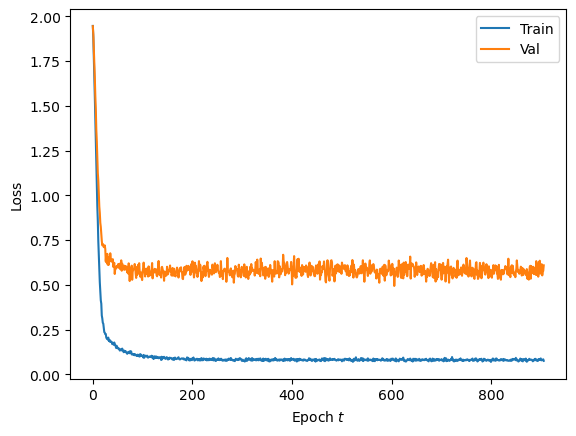

Accuracy of the model: 83.24%


In [6]:
train_statistics = experiment_train.run(
    data_dir = './data',
    dataset = DATASET,
    model_params = dict(
        label="Vanilla GCN",
        model="GCN",
        do_cache_adj_prep=True,
        n_filters=64,
        dropout=0.5,
        svd_params=None,
        jaccard_params=None,
        gdc_params={"alpha": 0.15, "k": 64}),
    train_params = dict(
        lr=1e-2,
        weight_decay=1e-3,
        patience=300,
        max_epochs=3000),
    binary_attr = False,
    make_undirected = True,
    seed=SEED,
    artifact_dir = 'cache',
    model_storage_type = 'demo',
    ppr_cache_params = dict(),
    #device = 0,
    #data_device = 0,
    device = "cpu",
    data_device = "cpu",
    display_steps = 100,
    debug_level = "info"
)

# plot train and val loss curves
fig, ax = plt.subplots()

color = plt.rcParams['axes.prop_cycle'].by_key()['color'][0]
ax.set_xlabel('Epoch $t$')
ax.set_ylabel("Loss")
ax.plot(train_statistics['trace_train'], color=color, label='Train')

color = plt.rcParams['axes.prop_cycle'].by_key()['color'][1]
ax.plot(train_statistics['trace_val'], color=color, label='Val')
ax.legend()
plt.show()

clean_acc = train_statistics["accuracy"]
print(f'Accuracy of the model: {100*clean_acc:.2f}%')

## 1.1 Certificate integration

In [7]:
# certificate integration
import torch
import numpy as np
import copy
from sparse_smoothing.models import GCN
from sparse_smoothing.utils import load_and_standardize

loaded_from_robustness = torch.load(f'cache/demo/demo_1.pt', map_location='cpu', weights_only=False)

trained_state_dict = copy.deepcopy(loaded_from_robustness)

for key in list(trained_state_dict.keys()):
    if 'layers.0.' in key:
        new_key = key.replace('layers.0.gcn_0', 'conv1')
        trained_state_dict[new_key] = trained_state_dict.pop(key)  # Transpose if necessary

for key in list(trained_state_dict.keys()):
    if 'layers.1.' in key:
        new_key = key.replace('layers.1.gcn_1', 'conv2')
        trained_state_dict[new_key] = trained_state_dict.pop(key)  # Transpose if necessary

In [8]:
graph = load_and_standardize(f"data/{DATASET}.npz")
n, d = graph.attr_matrix.shape
nc = graph.labels.max() + 1
pf_plus_att = 0.01
pf_minus_att = 0.6

In [9]:
model = GCN(n_features=d, n_classes=nc, n_hidden=64)#.cuda()
print(model)
# Load the modified state dictionary
model.load_state_dict(trained_state_dict)

GCN(
  (conv1): SparseGCNConv(2879, 64)
  (conv2): GCNConv(64, 7)
)


<All keys matched successfully>

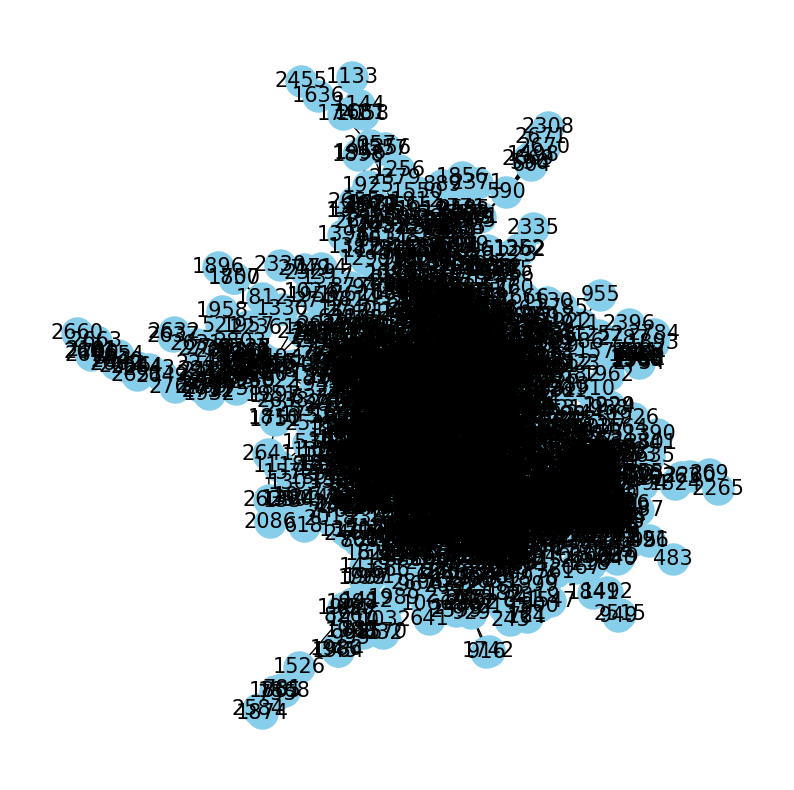

(2810, 2810)


In [10]:
from torch_geometric.utils import to_networkx
import networkx as nx

adj_numpy = graph.adj_matrix.toarray()
y_numpy = graph.labels

# Convert numpy adjacency matrix to networkx graph
G = nx.from_numpy_array(adj_numpy)

#G = to_networkx(graph.adj_matrix.toarray(), to_undirected=True)
plt.figure(figsize=(10, 10))
plt.axis('off')
nx.draw(G, with_labels=True, node_color='skyblue', node_size=500, font_size=15)
plt.show()
print(adj_numpy.shape)

In [11]:
print(adj_numpy.shape)
print(y_numpy.shape)

(2810, 2810)
(2810,)


In [12]:
edge_idx = torch.LongTensor(np.stack(graph.adj_matrix.nonzero()))#.cuda()
attr_idx = torch.LongTensor(np.stack(graph.attr_matrix.nonzero()))#.cuda()

## 2. Evaluation

For evaluation, we use the locally stored models. Similarly to training, we provide a script that runs the attacks for different seeds for all pretrained models. For all experiments, please check out the [config](https://github.com/sigeisler/robustness_of_gnns_at_scale/tree/main/config) folder.

### 2.1 Local PR-BCD Attack with grid_radii initialization
We provide an example for a `local PR-BCD` attack on the `Vanilla GCN` model trained previously by passing the desired configuration in [experiments/experiment_local_attack_direct.py](https://github.com/sigeisler/robustness_of_gnns_at_scale/blob/main/experiments/experiment_local_attack_direct.py#L68).

In [13]:
local_prbcd_statistics_cert = experiment_local_attack_direct.run(
    data_dir = './data',
    dataset = DATASET,
    attack = 'LocalPRBCD',
    attack_params = dict(
        ppr_cache_params = dict(
            data_artifact_dir = 'cache',
            data_storage_type = 'ppr'),
        #epochs = 500, # -> way too high for my setup, use 40-100
        epochs = 50,
        fine_tune_epochs = 100, #this may have to be adjusted to epochs
        search_space_size = 100, #is here the same varibale error as in global_attack ?
        block_size = 100,
        ppr_recalc_at_end = True,
        loss_type = 'Margin',
        lr_factor = 0.05),
    nodes = None,
    nodes_topk = 5,
    seed=SEED,
    epsilons = [1],
    min_node_degree = None,
    binary_attr = False,
    make_undirected = True,
    artifact_dir = 'cache',
    model_label = 'Vanilla GCN',
    model_storage_type = 'demo',
    #device = 0,
    #data_device = 0,
    device = "cpu",
    data_device = "cpu",
    debug_level = "info",
    grid_radii=None, #grid_radii still in here
    use_cert=True,
)

[03/22/26 12:07:40] INFO     {'dataset': 'cora_ml', 'attack': 'LocalPRBCD', 'attack_params':           ]8;id=933961;file://E:\Masterarbeit\AttackerGNN\experiments\common.py\common.py]8;;\:]8;id=724824;file://E:\Masterarbeit\AttackerGNN\experiments\common.py#38\38]8;;\
                             {'ppr_cache_params': {'data_artifact_dir': 'cache', 'data_storage_type':              
                             'ppr'}, 'epochs': 50, 'fine_tune_epochs': 100, 'search_space_size': 100,              
                             'block_size': 100, 'ppr_recalc_at_end': True, 'loss_type': 'Margin',                  
                             'lr_factor': 0.05}, 'epsilons': [1], 'make_undirected': True,                         
                             'binary_attr': False, 'seed': 1, 'artifact_dir': 'cache',                             
                             'pert_adj_storage_type': None, 'pert_attr_storage_type': None,                        
                             'model_label': 'Vanilla GCN', 'model_storage_type': 'demo', 'device':                 
                             'cpu', 'data_device': 'cpu'}                                                          

                    INFO     Lock 2331922659856 acquired on cache\demo.json.lock                    ]8;id=122016;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py\filelock.py]8;;\:]8;id=818900;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py#274\274]8;;\

                    INFO     Lock 2331922659856 released on cache\demo.json.lock                    ]8;id=777855;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py\filelock.py]8;;\:]8;id=307716;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py#318\318]8;;\

                    INFO     Found 1 models with label 'Vanilla GCN' to       ]8;id=61010;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_local_attack_direct.py\experiment_local_attack_direct.py]8;;\:]8;id=87952;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_local_attack_direct.py#141\141]8;;\
                             attack.                                                                               

                    INFO     Sample Attack Nodes for model with accuracy 0.8324                       ]8;id=560632;file://E:\Masterarbeit\AttackerGNN\experiments\common.py\common.py]8;;\:]8;id=736283;file://E:\Masterarbeit\AttackerGNN\experiments\common.py#187\187]8;;\

...

                    ERROR    missing a required argument: 'graph'             ]8;id=763523;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_local_attack_direct.py\experiment_local_attack_direct.py]8;;\:]8;id=713206;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_local_attack_direct.py#188\188]8;;\
                             Traceback (most recent call last):                                                    
                               File                                                                                
                             "E:\Masterarbeit\AttackerGNN\experiments\experim                                      
                             ent_local_attack_direct.py", line 186, in run                                         
                                 adversary.attack(n_perturbations,                                                 
                             node_idx=node, grid_radii=grid_radii)                                                 
                               File                                                                                
                             "E:\Anaconda\envs\Masterarbeit\Lib\site-packages                                      
                             \typeguard\__init__.py", line 1031, in wrapper                                        
                                 memo = _CallMemo(python_func, _localns,                                           
                             args=args, kwargs=kwargs)                                                             
                                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^                                      
                             ^^^^^^^^^^^^^^^^^^^^^                                                                 
                               File                                                                                
                             "E:\Anaconda\envs\Masterarbeit\Lib\site-packages                                      
                             \typeguard\__init__.py", line 198, in __init__                                        
                                 self.arguments = signature.bind(*args,                                            
                             **kwargs).arguments                                                                   
                                                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^                                      
                             ^^^^                                                                                  
                               File                                                                                
                             "E:\Anaconda\envs\Masterarbeit\Lib\inspect.py",                                       
                             line 3195, in bind                                                                    
                                 return self._bind(args, kwargs)                                                   
                                        ^^^^^^^^^^^^^^^^^^^^^^^^                                                   
                               File                                                                                
                             "E:\Anaconda\envs\Masterarbeit\Lib\inspect.py",                                       
                             line 3110, in _bind                                                                   
                                 raise TypeError(msg) from None                                                    
                             TypeError: missing a required argument: 'graph'                                       

                    ERROR    Failed to attack model 'Vanilla GCN' using       ]8;id=883930;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_local_attack_direct.py\experiment_local_attack_direct.py]8;;\:]8;id=409165;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_local_attack_direct.py#189\189]8;;\
                             LocalPRBCD with eps 1 at node 530.                                                    

                    ERROR    missing a required argument: 'graph'             ]8;id=724010;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_local_attack_direct.py\experiment_local_attack_direct.py]8;;\:]8;id=435541;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_local_attack_direct.py#188\188]8;;\
                             Traceback (most recent call last):                                                    
                               File                                                                                
                             "E:\Masterarbeit\AttackerGNN\experiments\experim                                      
                             ent_local_attack_direct.py", line 186, in run                                         
                                 adversary.attack(n_perturbations,                                                 
                             node_idx=node, grid_radii=grid_radii)                                                 
                               File                                                                                
                             "E:\Anaconda\envs\Masterarbeit\Lib\site-packages                                      
                             \typeguard\__init__.py", line 1031, in wrapper                                        
                                 memo = _CallMemo(python_func, _localns,                                           
                             args=args, kwargs=kwargs)                                                             
                                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^                                      
                             ^^^^^^^^^^^^^^^^^^^^^                                                                 
                               File                                                                                
                             "E:\Anaconda\envs\Masterarbeit\Lib\site-packages                                      
                             \typeguard\__init__.py", line 198, in __init__                                        
                                 self.arguments = signature.bind(*args,                                            
                             **kwargs).arguments                                                                   
                                                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^                                      
                             ^^^^                                                                                  
                               File                                                                                
                             "E:\Anaconda\envs\Masterarbeit\Lib\inspect.py",                                       
                             line 3195, in bind                                                                    
                                 return self._bind(args, kwargs)                                                   
                                        ^^^^^^^^^^^^^^^^^^^^^^^^                                                   
                               File                                                                                
                             "E:\Anaconda\envs\Masterarbeit\Lib\inspect.py",                                       
                             line 3110, in _bind                                                                   
                                 raise TypeError(msg) from None                                                    
                             TypeError: missing a required argument: 'graph'                                       

                    ERROR    Failed to attack model 'Vanilla GCN' using       ]8;id=931356;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_local_attack_direct.py\experiment_local_attack_direct.py]8;;\:]8;id=583988;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_local_attack_direct.py#189\189]8;;\
                             LocalPRBCD with eps 1 at node 2768.                                                   

AssertionError: 

In [ ]:
n_change = 0
for node in local_prbcd_statistics_cert['results']:
    if node['margin'] < 0:
        n_change += 1
flipped_ratio_cert =  n_change / len(local_prbcd_statistics_cert['results'])
print(f'Percentage of changed node predictions for init with cert : {100*flipped_ratio_cert:.2f}%')

### 2.1.1 Local PR-BCD Attack without grid_radii initialization
We provide an example for a `local PR-BCD` attack on the `Vanilla GCN` model trained previously by passing the desired configuration in [experiments/experiment_local_attack_direct.py](https://github.com/sigeisler/robustness_of_gnns_at_scale/blob/main/experiments/experiment_local_attack_direct.py#L68).

In [13]:
local_prbcd_statistics = experiment_local_attack_direct.run(
    data_dir = './data',
    dataset = DATASET,
    attack = 'LocalPRBCD',
    attack_params = dict(
        ppr_cache_params = dict(
            data_artifact_dir = 'cache',
            data_storage_type = 'ppr'),
        #epochs = 500, # -> way too high for my setup, use 40-100
        epochs = 50,
        fine_tune_epochs = 100,
        search_space_size = 100,
        block_size = 100,
        ppr_recalc_at_end = True,
        loss_type = 'Margin',
        lr_factor = 0.05),
    nodes = None,
    nodes_topk = 5,
    seed=SEED,
    epsilons = [1],
    min_node_degree = None,
    binary_attr = False,
    make_undirected = True,
    artifact_dir = 'cache',
    model_label = 'Vanilla GCN',
    model_storage_type = 'demo',
    #device = 0,
    #data_device = 0,
    device = "cpu",
    data_device = "cpu",
    debug_level = "info",
    grid_radii=None #grid_radii still in here
)

[02/01/26 11:50:11] INFO     {'dataset': 'cora_ml', 'attack': 'LocalPRBCD', 'attack_params':           ]8;id=323927;file://E:\Masterarbeit\AttackerGNN\experiments\common.py\common.py]8;;\:]8;id=624759;file://E:\Masterarbeit\AttackerGNN\experiments\common.py#38\38]8;;\
                             {'ppr_cache_params': {'data_artifact_dir': 'cache', 'data_storage_type':              
                             'ppr'}, 'epochs': 50, 'fine_tune_epochs': 100, 'search_space_size': 100,              
                             'block_size': 100, 'ppr_recalc_at_end': True, 'loss_type': 'Margin',                  
                             'lr_factor': 0.05}, 'epsilons': [1], 'make_undirected': True,                         
                             'binary_attr': False, 'seed': 1, 'artifact_dir': 'cache',                             
                             'pert_adj_storage_type': None, 'pert_attr_storage_type': None,                        
                             'model_label': 'Vanilla GCN', 'model_storage_type': 'demo', 'device':                 
                             'cpu', 'data_device': 'cpu'}                                                          

                    INFO     Lock 1998672643152 acquired on cache\demo.json.lock                    ]8;id=153443;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py\filelock.py]8;;\:]8;id=219915;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py#274\274]8;;\

                    INFO     Lock 1998672643152 released on cache\demo.json.lock                    ]8;id=861890;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py\filelock.py]8;;\:]8;id=354254;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py#318\318]8;;\

                    INFO     Found 1 models with label 'Vanilla GCN' to       ]8;id=252702;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_local_attack_direct.py\experiment_local_attack_direct.py]8;;\:]8;id=582876;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_local_attack_direct.py#141\141]8;;\
                             attack.                                                                               

[02/01/26 11:50:12] INFO     Sample Attack Nodes for model with accuracy 0.8324                       ]8;id=403802;file://E:\Masterarbeit\AttackerGNN\experiments\common.py\common.py]8;;\:]8;id=544570;file://E:\Masterarbeit\AttackerGNN\experiments\common.py#187\187]8;;\

...

                    ERROR    missing a required argument: 'graph'             ]8;id=703730;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_local_attack_direct.py\experiment_local_attack_direct.py]8;;\:]8;id=241874;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_local_attack_direct.py#188\188]8;;\
                             Traceback (most recent call last):                                                    
                               File                                                                                
                             "E:\Masterarbeit\AttackerGNN\experiments\experim                                      
                             ent_local_attack_direct.py", line 186, in run                                         
                                 adversary.attack(n_perturbations,                                                 
                             node_idx=node, grid_radii=grid_radii)                                                 
                               File                                                                                
                             "E:\Anaconda\envs\Masterarbeit\Lib\site-packages                                      
                             \typeguard\__init__.py", line 1031, in wrapper                                        
                                 memo = _CallMemo(python_func, _localns,                                           
                             args=args, kwargs=kwargs)                                                             
                                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^                                      
                             ^^^^^^^^^^^^^^^^^^^^^                                                                 
                               File                                                                                
                             "E:\Anaconda\envs\Masterarbeit\Lib\site-packages                                      
                             \typeguard\__init__.py", line 198, in __init__                                        
                                 self.arguments = signature.bind(*args,                                            
                             **kwargs).arguments                                                                   
                                                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^                                      
                             ^^^^                                                                                  
                               File                                                                                
                             "E:\Anaconda\envs\Masterarbeit\Lib\inspect.py",                                       
                             line 3195, in bind                                                                    
                                 return self._bind(args, kwargs)                                                   
                                        ^^^^^^^^^^^^^^^^^^^^^^^^                                                   
                               File                                                                                
                             "E:\Anaconda\envs\Masterarbeit\Lib\inspect.py",                                       
                             line 3110, in _bind                                                                   
                                 raise TypeError(msg) from None                                                    
                             TypeError: missing a required argument: 'graph'                                       

                    ERROR    Failed to attack model 'Vanilla GCN' using       ]8;id=676020;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_local_attack_direct.py\experiment_local_attack_direct.py]8;;\:]8;id=442854;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_local_attack_direct.py#189\189]8;;\
                             LocalPRBCD with eps 1 at node 530.                                                    

                    ERROR    missing a required argument: 'graph'             ]8;id=379400;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_local_attack_direct.py\experiment_local_attack_direct.py]8;;\:]8;id=735566;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_local_attack_direct.py#188\188]8;;\
                             Traceback (most recent call last):                                                    
                               File                                                                                
                             "E:\Masterarbeit\AttackerGNN\experiments\experim                                      
                             ent_local_attack_direct.py", line 186, in run                                         
                                 adversary.attack(n_perturbations,                                                 
                             node_idx=node, grid_radii=grid_radii)                                                 
                               File                                                                                
                             "E:\Anaconda\envs\Masterarbeit\Lib\site-packages                                      
                             \typeguard\__init__.py", line 1031, in wrapper                                        
                                 memo = _CallMemo(python_func, _localns,                                           
                             args=args, kwargs=kwargs)                                                             
                                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^                                      
                             ^^^^^^^^^^^^^^^^^^^^^                                                                 
                               File                                                                                
                             "E:\Anaconda\envs\Masterarbeit\Lib\site-packages                                      
                             \typeguard\__init__.py", line 198, in __init__                                        
                                 self.arguments = signature.bind(*args,                                            
                             **kwargs).arguments                                                                   
                                                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^                                      
                             ^^^^                                                                                  
                               File                                                                                
                             "E:\Anaconda\envs\Masterarbeit\Lib\inspect.py",                                       
                             line 3195, in bind                                                                    
                                 return self._bind(args, kwargs)                                                   
                                        ^^^^^^^^^^^^^^^^^^^^^^^^                                                   
                               File                                                                                
                             "E:\Anaconda\envs\Masterarbeit\Lib\inspect.py",                                       
                             line 3110, in _bind                                                                   
                                 raise TypeError(msg) from None                                                    
                             TypeError: missing a required argument: 'graph'                                       

                    ERROR    Failed to attack model 'Vanilla GCN' using       ]8;id=595648;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_local_attack_direct.py\experiment_local_attack_direct.py]8;;\:]8;id=104438;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_local_attack_direct.py#189\189]8;;\
                             LocalPRBCD with eps 1 at node 2768.                                                   

AssertionError: 

In [ ]:
n_change = 0
for node in local_prbcd_statistics['results']:
    if node['margin'] < 0:
        n_change += 1
flipped_ratio =  n_change / len(local_prbcd_statistics['results'])
print(f'Percentage of changed node predictions : {100*flipped_ratio:.2f}%')

In [ ]:
n_change = 0
for node in local_prbcd_statistics_cert['results']:
    if node['margin'] < 0:
        n_change += 1
flipped_ratio_cert =  n_change / len(local_prbcd_statistics_cert['results'])
print(f'Percentage of changed node predictions for init with cert : {100*flipped_ratio_cert:.2f}%')

### 2.2 Global PR-BCD Attack with Cert

Now let's do the same with a non-local `PR-BCD` attack. For this, we use [experiments/experiment_global_attack_direct.py](https://github.com/sigeisler/robustness_of_gnns_at_scale/blob/main/experiments/experiment_global_attack_direct.py#L63).

In [18]:
# =========================
# Sweep config: PR-BCD / ATTACK PARAMS
# =========================

results_global_prbcd_cert = []

attack_sweep = {
    # experiment-level attack settings
    "semi": [True],
    "epsilon": [0.1],
    "use_cert": [
        "selector_direct"
    ],

    # PR-BCD-internal params
    "block_size": [10_000],
    "epochs": [100],
    "fine_tune_epochs": [50],
    "keep_heuristic": ["WeightOnly"],
    "search_space_size": [100_000],
    "do_synchronize": [True],
    "loss_type": ["tanhMargin"],
}

# =========================
# Sweep config: SELECTOR / PRESELECTION PARAMS
# =========================

selector_sweep = {
    # ADS-specific selector/preselection mode
    # These should ONLY be swept for use_cert in ads_certs.
    "accuracy_drop_selector_mode": [
        "one_sample",
        "node_matching",
    ],  # "k_hop", "one_sample", "k_action", "node_matching"

    # ADS-specific candidate labeling
    # These should ONLY be assigned for use_cert in ads_certs.
    "n_candidates_k_sample": [2000],
    "n_candidates_one_sample": [5000],
    "drop_mode": ["endpoint"],
    "acc_drop_threshold_k_samples": [1e-3],
    "loss_drop_threshold_k_samples": [1e-3],
    "k_samples_batch": [10],

    # LP / selector block construction
    # These can still be passed for non-ADS configs if you want them available.
    "tau": [0.8],
    "score_batch_size": [1000],
    "max_sampling_tries": [2_000_000],
    "exclude_tried": [True],

    # optional / future params
    # "subgraph_fraction": [0.33],
    # "tau_decay": [None],
    # "aux_loss_weight": [None],
}

# =========================
# Sweep definitions
# =========================

from itertools import product
from copy import deepcopy

ads_certs = {
    "accuracy_drop_selector",
    "accuracy_drop_selector_with_resampling",
    "selector_direct"
}

# Params that should only exist for ADS configs
ADS_ONLY_SELECTOR_COLUMNS = {
    "accuracy_drop_selector_mode",
    "n_candidates_k_sample",
    "n_candidates_one_sample",
    "drop_mode",
    "acc_drop_threshold_k_samples",
    "loss_drop_threshold_k_samples",
    "k_samples_batch",
}

# Params that may still be useful/loggable for non-ADS configs
BASE_SELECTOR_COLUMNS = [
    col for col in selector_sweep.keys()
    if col not in ADS_ONLY_SELECTOR_COLUMNS
]

ATTACK_COLUMNS = list(attack_sweep.keys())
SELECTOR_COLUMNS = list(selector_sweep.keys())

ALL_SWEEP_COLUMNS = (
    [f"attack__{col}" for col in ATTACK_COLUMNS]
    + [f"selector__{col}" for col in SELECTOR_COLUMNS]
)


def expand_grid(grid):
    keys = list(grid.keys())
    value_lists = [grid[k] for k in keys]

    for values in product(*value_lists):
        yield dict(zip(keys, values))


def filter_grid(grid, keep_columns):
    """
    Keeps only selected columns from a sweep grid.
    """
    return {
        key: values
        for key, values in grid.items()
        if key in keep_columns
    }


def build_sweep_configs():
    configs = []

    ads_selector_sweep = selector_sweep
    base_selector_sweep = filter_grid(
        selector_sweep,
        BASE_SELECTOR_COLUMNS,
    )

    for attack_cfg in expand_grid(attack_sweep):
        use_cert = attack_cfg["use_cert"]

        if use_cert in ads_certs:
            # ADS configs:
            # Sweep over accuracy_drop_selector_mode, drop_mode, candidate labeling,
            # and LP/block-construction params.
            for selector_cfg in expand_grid(ads_selector_sweep):
                configs.append({
                    "attack_params": deepcopy(attack_cfg),
                    "selector_params": deepcopy(selector_cfg),
                })

        else:
            # Non-ADS configs:
            # Do NOT sweep or assign accuracy_drop_selector_mode or drop_mode.
            # Still pass base selector params like tau, score_batch_size,
            # max_sampling_tries, exclude_tried.
            for selector_cfg in expand_grid(base_selector_sweep):
                configs.append({
                    "attack_params": deepcopy(attack_cfg),
                    "selector_params": deepcopy(selector_cfg),
                })

    return configs


def _cfg_to_row(cfg):
    row = {}

    attack_params = cfg.get("attack_params", {})
    selector_params = cfg.get("selector_params", {})

    for col in ATTACK_COLUMNS:
        row[f"attack__{col}"] = attack_params.get(col, "")

    for col in SELECTOR_COLUMNS:
        row[f"selector__{col}"] = selector_params.get(col, "")

    return row


sweep_configs = build_sweep_configs()
number_loops = len(sweep_configs)

print("number_loops:", number_loops)

# Optional sanity check
for i, cfg in enumerate(sweep_configs, start=1):
    attack_params = cfg["attack_params"]
    selector_params = cfg["selector_params"]

    use_cert = attack_params["use_cert"]
    eps = attack_params["epsilon"]
    ads_mode = selector_params.get("accuracy_drop_selector_mode", "")
    drop_mode = selector_params.get("drop_mode", "")

    print(
        i,
        "use_cert:", use_cert,
        "epsilon:", eps,
        "ads_mode:", ads_mode,
        "drop_mode:", drop_mode,
        "selector_params:", selector_params,
    )

number_loops: 2
1 use_cert: selector_direct epsilon: 0.1 ads_mode: one_sample drop_mode: endpoint selector_params: {'accuracy_drop_selector_mode': 'one_sample', 'n_candidates_k_sample': 2000, 'n_candidates_one_sample': 5000, 'drop_mode': 'endpoint', 'acc_drop_threshold_k_samples': 0.001, 'loss_drop_threshold_k_samples': 0.001, 'k_samples_batch': 10, 'tau': 0.8, 'score_batch_size': 1000, 'max_sampling_tries': 2000000, 'exclude_tried': True}
2 use_cert: selector_direct epsilon: 0.1 ads_mode: node_matching drop_mode: endpoint selector_params: {'accuracy_drop_selector_mode': 'node_matching', 'n_candidates_k_sample': 2000, 'n_candidates_one_sample': 5000, 'drop_mode': 'endpoint', 'acc_drop_threshold_k_samples': 0.001, 'loss_drop_threshold_k_samples': 0.001, 'k_samples_batch': 10, 'tau': 0.8, 'score_batch_size': 1000, 'max_sampling_tries': 2000000, 'exclude_tried': True}


In [ ]:
from DeleteCache import delete_pert_files_and_folders
from IPython.display import clear_output
from timeit import default_timer as timer
from itertools import zip_longest
from copy import deepcopy
import csv
import os
import time

# =========================
# Output locations
# =========================

OUT_DIR = "."
os.makedirs(OUT_DIR, exist_ok=True)

# =========================
# CSV schemas
# =========================

summary_header = (
    ["run_id", "use_cert_label", "seed", "accuracy", "time"]
    + ALL_SWEEP_COLUMNS
)

epochs_header = (
    [
        "run_id", "use_cert_label", "seed", "epoch_idx",
        "accuracy", "loss", "nonzero_weights",
        "prob_mass_update", "prob_mass_projected",
    ]
    + ALL_SWEEP_COLUMNS
)

RESET_CSVS = False

def _open_writer(path, fieldnames):
    file_exists = os.path.isfile(path)

    if file_exists:
        with open(path, newline="") as r:
            reader = csv.reader(r)
            on_disk = next(reader, None)

        if on_disk != fieldnames:
            raise RuntimeError(
                f"Header mismatch in {path}.\n"
                f"Found:  {on_disk}\n"
                f"Expect: {fieldnames}\n"
                f"Rename/delete the file or set RESET_CSVS=True once."
            )

    f = open(path, "a", newline="")
    w = csv.DictWriter(f, fieldnames=fieldnames)

    if not file_exists:
        w.writeheader()

    return f, w


# =====================
# Param-tagged CSV filenames
# =========================

def _slug(x):
    s = str(x)
    return (
        s.replace(" ", "")
         .replace(".", "p")
         .replace("/", "_")
         .replace("\\", "_")
         .replace(":", "-")
    )

def _join_slug(seq):
    return "+".join(_slug(v) for v in seq)

STAMP = time.strftime("%y%m%d-%H%M%S")

PARAM_TAG = (
    f"ds{_slug(DATASET)}"
    f"__bs{_join_slug(attack_sweep['block_size'])}"
    f"__eps{_join_slug(attack_sweep['epsilon'])}"
    f"__ep{_join_slug(attack_sweep['epochs'])}"
    f"__ft{_join_slug(attack_sweep['fine_tune_epochs'])}"
    f"__cert{_join_slug(attack_sweep['use_cert'])}"
)

SUMMARY_CSV = os.path.join(
    OUT_DIR,
    f"global_prbcd_cert_results__{PARAM_TAG}__{STAMP}.csv",
)

EPOCHS_CSV = os.path.join(
    OUT_DIR,
    f"global_prbcd_cert_epochs__{PARAM_TAG}__{STAMP}.csv",
)

if RESET_CSVS:
    for p in (SUMMARY_CSV, EPOCHS_CSV):
        if os.path.exists(p):
            os.remove(p)

_open_writer(SUMMARY_CSV, summary_header)[0].close()
_open_writer(EPOCHS_CSV, epochs_header)[0].close()

# =========================
# Loop setup
# =========================

results_global_prbcd_cert = []

number_loops = len(sweep_configs)
loop = 1

ads_certs = {
    "accuracy_drop_selector",
    "accuracy_drop_selector_with_resampling",
}

edge_idx = torch.LongTensor(np.stack(graph.adj_matrix.nonzero()))
attr_idx = torch.LongTensor(np.stack(graph.attr_matrix.nonzero()))

for cfg in sweep_configs:
    attack_params_full = deepcopy(cfg["attack_params"])
    selector_params = deepcopy(cfg["selector_params"])

    # These are experiment-level args, not PRBCD constructor/attack_params args.
    semi = attack_params_full["semi"]
    epsilon = attack_params_full["epsilon"]
    use_cert = attack_params_full["use_cert"]

    ads_mode = selector_params.get("accuracy_drop_selector_mode")

    if use_cert in ads_certs and ads_mode is not None:
        use_cert_label = f"{use_cert}_{ads_mode}"
    else:
        use_cert_label = use_cert

    # Only these go into experiment_global_attack_direct.run(..., attack_params=...)
    prbcd_attack_params = {
        k: v
        for k, v in attack_params_full.items()
        if k not in {"semi", "epsilon", "use_cert"}
    }

    run_id = (
        f"{int(time.time())}-"
        f"{use_cert_label}-"
        f"seed{SEED}-"
        f"eps{epsilon}-"
        f"bs{attack_params_full['block_size']}-"
        f"semi{int(semi)}-"
        f"ep{attack_params_full['epochs']}-"
        f"ft{attack_params_full['fine_tune_epochs']}"
    )

    delete_pert_files_and_folders(
        cache_dir="cache",
        pert_adj_storage_type="evasion_global_adj",
        pert_attr_storage_type="evasion_global_attr",
    )

    if "_direct" in use_cert:
        attack_sig = "SelectorAttack"
    else:
        attack_sig = "PRBCD"

    print("loop", loop, "of", number_loops)
    print("use_cert:", use_cert)
    print("selector_mode:", ads_mode)
    print("attack_params:", prbcd_attack_params)
    print("selector_params:", selector_params)
    loop += 1

    start = timer()

    global_prbcd_statistics_cert = experiment_global_attack_direct.run(
        graph=graph,
        data_dir="./data",
        dataset=DATASET,
        attack=attack_sig,

        attack_params=prbcd_attack_params,
        selector_params=selector_params,

        epsilons=[epsilon],
        binary_attr=False,
        make_undirected=True,
        seed=SEED,
        artifact_dir="cache",
        pert_adj_storage_type="evasion_global_adj",
        pert_attr_storage_type="evasion_global_attr",
        model_label="Vanilla GCN",
        model_storage_type="demo",
        device="cpu",
        data_device="cpu",
        debug_level="info",
        semi=semi,
        use_cert=use_cert,
    )

    elapsed = timer() - start

    # =========================
    # Final-accuracy summary row
    # =========================

    final_acc = global_prbcd_statistics_cert["results"][0]["accuracy"]

    summary_row = {
        "run_id": run_id,
        "use_cert_label": use_cert_label,
        "seed": SEED,
        "accuracy": final_acc,
        "time": elapsed,
    }

    summary_row.update(_cfg_to_row(cfg))

    f_sum, w_sum = _open_writer(SUMMARY_CSV, summary_header)
    w_sum.writerow(summary_row)
    f_sum.close()

    # =========================
    # Per-epoch logging
    # =========================

    stats = (
        global_prbcd_statistics_cert.get("attack_statistics")
        or global_prbcd_statistics_cert.get("stats")
        or global_prbcd_statistics_cert.get("attack_stats")
    )

    if stats:
        def _to_py(seq):
            out = []
            for v in seq:
                try:
                    out.append(float(v))
                except Exception:
                    out.append(v)
            return out

        acc_list = _to_py(stats.get("accuracy", []))
        loss_list = _to_py(stats.get("loss", []))
        nnz_list = _to_py(stats.get("nonzero_weights", []))
        pmu_list = _to_py(stats.get("probability_mass_update", []))
        pmp_list = _to_py(stats.get("probability_mass_projected", []))

        f_ep, w_ep = _open_writer(EPOCHS_CSV, epochs_header)

        for epoch_idx, acc, loss, nnz, pmu, pmp in zip_longest(
            range(len(acc_list)),
            acc_list,
            loss_list,
            nnz_list,
            pmu_list,
            pmp_list,
            fillvalue="",
        ):
            epoch_row = {
                "run_id": run_id,
                "use_cert_label": use_cert_label,
                "seed": SEED,
                "epoch_idx": epoch_idx,
                "accuracy": acc,
                "loss": loss,
                "nonzero_weights": nnz,
                "prob_mass_update": pmu,
                "prob_mass_projected": pmp,
            }

            epoch_row.update(_cfg_to_row(cfg))
            w_ep.writerow(epoch_row)

        f_ep.close()

    else:
        print("[warn] No attack_statistics found in result; per-epoch CSV skipped.")

    if "gradient" in global_prbcd_statistics_cert:
        print(global_prbcd_statistics_cert["gradient"])

    print("time:", elapsed)
    print(use_cert_label + ":")
    print(global_prbcd_statistics_cert)

    results_global_prbcd_cert.append((
        use_cert_label,
        "ACCURACY:",
        final_acc,
        "time:",
        elapsed,
        "semi:",
        semi,
    ))

    clear_output(wait=True)

Not found: cache\evasion_global_adj.json
Not found: cache\evasion_global_attr.json
Not found: cache\evasion_global_adj
Not found: cache\evasion_global_attr
loop 1 of 2
use_cert: selector_direct
selector_mode: one_sample
attack_params: {'block_size': 10000, 'epochs': 100, 'fine_tune_epochs': 50, 'keep_heuristic': 'WeightOnly', 'search_space_size': 100000, 'do_synchronize': True, 'loss_type': 'tanhMargin'}
selector_params: {'accuracy_drop_selector_mode': 'one_sample', 'n_candidates_k_sample': 2000, 'n_candidates_one_sample': 5000, 'drop_mode': 'endpoint', 'acc_drop_threshold_k_samples': 0.001, 'loss_drop_threshold_k_samples': 0.001, 'k_samples_batch': 10, 'tau': 0.8, 'score_batch_size': 1000, 'max_sampling_tries': 2000000, 'exclude_tried': True}


[05/10/26 12:00:52] INFO     {'dataset': 'cora_ml', 'attack': 'SelectorAttack', 'attack_params':       ]8;id=367975;file://E:\Masterarbeit\AttackerGNN\experiments\common.py\common.py]8;;\:]8;id=315471;file://E:\Masterarbeit\AttackerGNN\experiments\common.py#38\38]8;;\
                             {'block_size': 10000, 'epochs': 100, 'fine_tune_epochs': 50,                          
                             'keep_heuristic': 'WeightOnly', 'search_space_size': 100000,                          
                             'do_synchronize': True, 'loss_type': 'tanhMargin'}, 'epsilons': [0.1],                
                             'make_undirected': True, 'binary_attr': False, 'seed': 1, 'artifact_dir':             
                             'cache', 'pert_adj_storage_type': 'evasion_global_adj',                               
                             'pert_attr_storage_type': 'evasion_global_attr', 'model_label': 'Vanilla              
                             GCN', 'model_storage_type': 'demo', 'device': 'cpu', 'data_device':                   
                             'cpu'}                                                                                
[05/10/26 12:01:51] INFO     {'dataset': 'cora_ml', 'attack': 'SelectorAttack', 'attack_params':       ]8;id=447106;file://E:\Masterarbeit\AttackerGNN\experiments\common.py\common.py]8;;\:]8;id=150555;file://E:\Masterarbeit\AttackerGNN\experiments\common.py#38\38]8;;\
                             {'block_size': 10000, 'epochs': 100, 'fine_tune_epochs': 50,                          
                             'keep_heuristic': 'WeightOnly', 'search_space_size': 100000,                          
                             'do_synchronize': True, 'loss_type': 'tanhMargin'}, 'epsilons': [0.1],                
                             'make_undirected': True, 'binary_attr': False, 'seed': 1, 'artifact_dir':             
                             'cache', 'pert_adj_storage_type': 'evasion_global_adj',                               
                             'pert_attr_storage_type': 'evasion_global_attr', 'model_label': 'Vanilla              
                             GCN', 'model_storage_type': 'demo', 'device': 'cpu', 'data_device':                   
                             'cpu'}                                                                                

                    INFO     Lock 2571002158992 acquired on cache\demo.json.lock                    ]8;id=622271;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py\filelock.py]8;;\:]8;id=237152;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py#274\274]8;;\

                    INFO     Lock 2571002158992 released on cache\demo.json.lock                    ]8;id=271718;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py\filelock.py]8;;\:]8;id=14356;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py#318\318]8;;\

                    INFO     Evaluate SelectorAttack for model 'Vanilla      ]8;id=935637;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_global_attack_direct.py\experiment_global_attack_direct.py]8;;\:]8;id=472432;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_global_attack_direct.py#101\101]8;;\
                             GCN'.                                                                                 

...

[LP-GNN] Epoch 120/200 | train_loss=0.1341 | val_loss=0.4575 | val_acc=0.8395 | acc_pos=0.8520 | acc_neg=0.8270 | TP/FP/TN/FN=852/173/827/148 | p(min/mean/max)=0.000/0.501/1.000 | AUC=0.9046 | AP=0.8861 | best_auc=0.9046 (epoch 120)


[LP-GNN] Training:  68%|██████▊   | 136/200 [00:08<00:04, 15.27it/s, tr_loss=0.0937, va_loss=0.5005, va_acc=0.836, auc=0.905, ap=0.886, pat=0] 


[LP-GNN] Early stopping at epoch 137. Best auc=0.9048 at epoch 122.
[LP-GNN] Restored best model from epoch 122 (auc=0.9048).
[LP-GNN] Training complete. Metrics saved to 'Plotting_Data/SelectorGNNLogs\selector_gnn_dataset-cora_ml_ads-one_sample_k2000_kb10_drpmdendpoint_20260510_120234.csv'


[05/10/26 12:03:06] INFO                                                                      ]8;id=142970;file://E:\Masterarbeit\AttackerGNN\rgnn_at_scale\attacks\selectorAttack.py\selectorAttack.py]8;;\:]8;id=925353;file://E:\Masterarbeit\AttackerGNN\rgnn_at_scale\attacks\selectorAttack.py#276\276]8;;\
                             Before the attack - Loss: -0.6408612132072449 Accuracy: 83.241 %                      
                                                                                                                   

  0%|          | 0/100 [00:00<?, ?it/s]

## Class for extended plotting

In [18]:
from DeleteCache import delete_pert_files_and_folders
from IPython.display import clear_output
from timeit import default_timer as timer
from itertools import zip_longest
import csv
import os
import time

# =========================
# Output locations
# =========================

# Folder for spearman rho results
SPEARMAN_RESULTS_DIR = os.path.join("extendedPlotting", "spearmanRho")
os.makedirs(SPEARMAN_RESULTS_DIR, exist_ok=True)

# Epoch CSVs can stay in current directory (or change if you want)
EPOCHS_DIR = "."
os.makedirs(EPOCHS_DIR, exist_ok=True)

# =========================
# CSV schemas
# =========================
summary_header = [
    "run_id", "use_cert", "seed", "accuracy", "spearman_rho", "time",
    "epoch", "fine_tune_epoch", "epsilon", "block_size", "semi"
]
epochs_header  = [
    "run_id", "use_cert", "seed", "epoch_idx", "accuracy", "loss",
    "nonzero_weights", "prob_mass_update", "prob_mass_projected",
    "epsilon", "block_size", "semi", "total_epochs", "fine_tune_epochs"
]

# Whether to delete existing files with old headers (only applies if filenames collide)
RESET_CSVS = False  # set True once to delete existing files with old headers

def _open_writer(path, fieldnames):
    """
    Open a DictWriter that guarantees the header matches `fieldnames`.
    Raises if an existing file has a different header.
    """
    file_exists = os.path.isfile(path)
    if file_exists:
        with open(path, newline="") as r:
            reader = csv.reader(r)
            on_disk = next(reader, None)
        if on_disk != fieldnames:
            raise RuntimeError(
                f"Header mismatch in {path}.\n"
                f"Found:  {on_disk}\n"
                f"Expect: {fieldnames}\n"
                f"Rename/delete the file or set RESET_CSVS=True once."
            )
    f = open(path, "a", newline="")
    w = csv.DictWriter(f, fieldnames=fieldnames)
    if not file_exists:
        w.writeheader()
    return f, w

def _extract_single_spearman_rho(result_dict):
    """
    In your result, spearman_rho lives here (per your screenshot):
      result_dict["attack_statistics"]["spearman_rho"] == [<one value>]
    Returns float or "" if missing.
    """
    stats = (
        result_dict.get("attack_statistics")
        or result_dict.get("stats")
        or result_dict.get("attack_stats")
        or {}
    )
    v = stats.get("spearman_rho", None)
    if v is None:
        return ""
    if isinstance(v, (list, tuple)):
        return float(v[0]) if len(v) > 0 else ""
    try:
        return float(v)
    except Exception:
        return v

# =========================
# Sweep config
# =========================
results_global_prbcd_cert = []

partly_drawn_nodes = [True]
block_sizes       = [500000]
epsilons          = [0.05]
epochs_list       = [100]
fine_tune_epochs  = [25]
use_certificate   = ["jaccard_topk"]
accuracy_drop_selector_mode = ["one_sample", "node_matching"] # "k_hop", "one_sample", "k_action", "node_matching"

# =========================
# Param-tagged CSV filenames (+ short timestamp)
# =========================
def _slug(x):
    # make values filename-safe: 0.25 -> 0p25, spaces removed
    s = str(x)
    return s.replace(" ", "").replace(".", "p").replace("/", "_").replace("\\", "_").replace(":", "-")

def _join_slug(seq):
    # join a list into a compact token like a+b+c
    return "+".join(_slug(v) for v in seq)

# Small timestamp (YYMMDD-HHMMSS)
STAMP = time.strftime("%y%m%d-%H%M%S")

# Build a compact, informative parameter tag
PARAM_TAG = (
    f"ds{_slug(DATASET)}"
    f"bs{_join_slug(block_sizes)}"
    f"__eps{_join_slug(epsilons)}"
    f"__ep{_join_slug(epochs_list)}"
    f"__ft{_join_slug(fine_tune_epochs)}"
    f"__cert{_join_slug(use_certificate)}"
)

SUMMARY_CSV = os.path.join(
    SPEARMAN_RESULTS_DIR,
    f"global_prbcd_cert_results__{PARAM_TAG}__{STAMP}.csv"
)

EPOCHS_CSV  = os.path.join(
    EPOCHS_DIR,
    f"global_prbcd_cert_epochs__{PARAM_TAG}__{STAMP}.csv"
)


# Optionally clear existing CSVs if names collide (rare due to timestamp)
if RESET_CSVS:
    for p in (SUMMARY_CSV, EPOCHS_CSV):
        if os.path.exists(p):
            os.remove(p)

# Touch files / validate headers now
_open_writer(SUMMARY_CSV, summary_header)[0].close()
_open_writer(EPOCHS_CSV,  epochs_header)[0].close()

# =========================
# Derived loop count
# =========================
base_combinations = (
    len(partly_drawn_nodes)
    * len(block_sizes)
    * len(epsilons)
    * len(epochs_list)
    * len(fine_tune_epochs)
)

has_ads = "accuracy_drop_selector" or "direct_attack" in use_certificate
num_other_certs = len(use_certificate) - (1 if has_ads else 0)

number_loops = base_combinations * (
    num_other_certs + (len(accuracy_drop_selector_mode) if has_ads else 0)
)
loop = 1

edge_idx = torch.LongTensor(np.stack(graph.adj_matrix.nonzero()))
attr_idx = torch.LongTensor(np.stack(graph.attr_matrix.nonzero()))

for semi in partly_drawn_nodes:
    for block_size in block_sizes:
        for epsilon in epsilons:
            for total_epochs in epochs_list:
                for ft_epochs in fine_tune_epochs:
                    for use_cert in use_certificate:

                        # choose modes only for accuracy_drop_selector
                        if use_cert in ("block_eval_selector", "block_eval_random"):
                            modes = accuracy_drop_selector_mode
                        else:
                            modes = [None]

                        for ads_mode in modes:
                            # Decorated label for CSV / run_id
                            if use_cert == "accuracy_drop_selector" and ads_mode is not None:
                                use_cert_label = f"{use_cert}_{ads_mode}"
                            else:
                                use_cert_label = use_cert

                            # Unique ID per run (include label)
                            run_id = (
                                f"{int(time.time())}-"
                                f"{use_cert_label}-"
                                f"seed{SEED}-"
                                f"eps{epsilon}-bs{block_size}-"
                                f"semi{int(semi)}-ep{total_epochs}-ft{ft_epochs}"
                            )

                            delete_pert_files_and_folders(
                                cache_dir="cache",
                                pert_adj_storage_type="evasion_global_adj",
                                pert_attr_storage_type="evasion_global_attr"
                            )
                            print("loop", loop, "of", number_loops)
                            loop += 1

                            attack_params = dict(
                                epochs=total_epochs,
                                fine_tune_epochs=ft_epochs,
                                keep_heuristic="WeightOnly",
                                search_space_size=100_000,
                                block_size=block_size,
                                do_synchronize=True,
                                loss_type="tanhMargin",
                            )
                            # optional: pass mode into the attack
                            if use_cert == "accuracy_drop_selector" and ads_mode is not None:
                                attack_params["accuracy_drop_selector_mode"] = ads_mode

                            start = timer()
                            global_prbcd_statistics_cert = experiment_global_attack_direct.run(
                                ads_mode=ads_mode,
                                graph=graph,
                                data_dir='./data',
                                dataset=DATASET,
                                attack='PRBCDExtendedPlotting', #'SelectorAttack' 'PRBCD' 'PRBCDExtendedPlotting'
                                attack_params=attack_params,
                                epsilons=[epsilon],
                                binary_attr=False,
                                make_undirected=True,
                                seed=SEED,
                                artifact_dir='cache',
                                pert_adj_storage_type='evasion_global_adj',
                                pert_attr_storage_type='evasion_global_attr',
                                model_label='Vanilla GCN',
                                model_storage_type='demo',
                                device="cpu",
                                data_device="cpu",
                                debug_level="info",
                                semi=semi,
                                use_cert=use_cert,
                            )
                            elapsed = timer() - start

                            # =========================
                            # Final-accuracy summary row (+ spearman_rho)
                            # =========================
                            final_acc = global_prbcd_statistics_cert["results"][0]["accuracy"]
                            spearman_rho = _extract_single_spearman_rho(global_prbcd_statistics_cert)

                            f_sum, w_sum = _open_writer(SUMMARY_CSV, summary_header)
                            w_sum.writerow({
                                "run_id": run_id,
                                "use_cert": use_cert_label,
                                "seed": SEED,
                                "accuracy": final_acc,
                                "spearman_rho": spearman_rho,
                                "time": elapsed,
                                "epoch": total_epochs,
                                "fine_tune_epoch": ft_epochs,
                                "epsilon": epsilon,
                                "block_size": block_size,
                                "semi": semi,
                            })
                            f_sum.close()

                            # =========================
                            # Per-epoch logging
                            # =========================
                            stats = (
                                global_prbcd_statistics_cert.get("attack_statistics")
                                or global_prbcd_statistics_cert.get("stats")
                                or global_prbcd_statistics_cert.get("attack_stats")
                            )

                            if stats:
                                def _to_py(seq):
                                    out = []
                                    for v in seq:
                                        try:
                                            out.append(float(v))
                                        except Exception:
                                            out.append(v)
                                    return out

                                acc_list  = _to_py(stats.get("accuracy", []))
                                loss_list = _to_py(stats.get("loss", []))
                                nnz_list  = _to_py(stats.get("nonzero_weights", []))
                                pmu_list  = _to_py(stats.get("probability_mass_update", []))
                                pmp_list  = _to_py(stats.get("probability_mass_projected", []))

                                f_ep, w_ep = _open_writer(EPOCHS_CSV, epochs_header)
                                for epoch_idx, acc, loss, nnz, pmu, pmp in zip_longest(
                                    range(len(acc_list)), acc_list, loss_list, nnz_list, pmu_list, pmp_list, fillvalue=""
                                ):
                                    w_ep.writerow({
                                        "run_id": run_id,
                                        "use_cert": use_cert_label,
                                        "seed": SEED,
                                        "epoch_idx": epoch_idx,  # 0 may be "pre-attack" entry
                                        "accuracy": acc,
                                        "loss": loss,
                                        "nonzero_weights": nnz,
                                        "prob_mass_update": pmu,
                                        "prob_mass_projected": pmp,
                                        "epsilon": epsilon,
                                        "block_size": block_size,
                                        "semi": semi,
                                        "total_epochs": total_epochs,
                                        "fine_tune_epochs": ft_epochs,
                                    })
                                f_ep.close()
                            else:
                                print("[warn] No attack_statistics found in result; per-epoch CSV skipped.")

                            # Optional: print gradient info if present
                            if "gradient" in global_prbcd_statistics_cert:
                                print(global_prbcd_statistics_cert["gradient"])

                            print("time:", elapsed)
                            print(use_cert_label + ":")
                            print(global_prbcd_statistics_cert)

                            results_global_prbcd_cert.append((
                                use_cert_label, "ACCURACY:", final_acc, "SPEARMAN_RHO:", spearman_rho,
                                "time:", elapsed, "semi:", semi
                            ))
                            clear_output(wait=True)

# Pretty print
def printItem(item):
    print(item)
    print("\n")

print("RESULTS")
[printItem(item) for item in results_global_prbcd_cert]


[None]

### 2.2.0 Pandas data analysis

#### 2.2.1 SelectorGNN Logs

Found 1 CSV files.

 Plotting: selector_gnn_ads-one_sample_k2000_kb10_drpmdendpoint_20260120_111500.csv


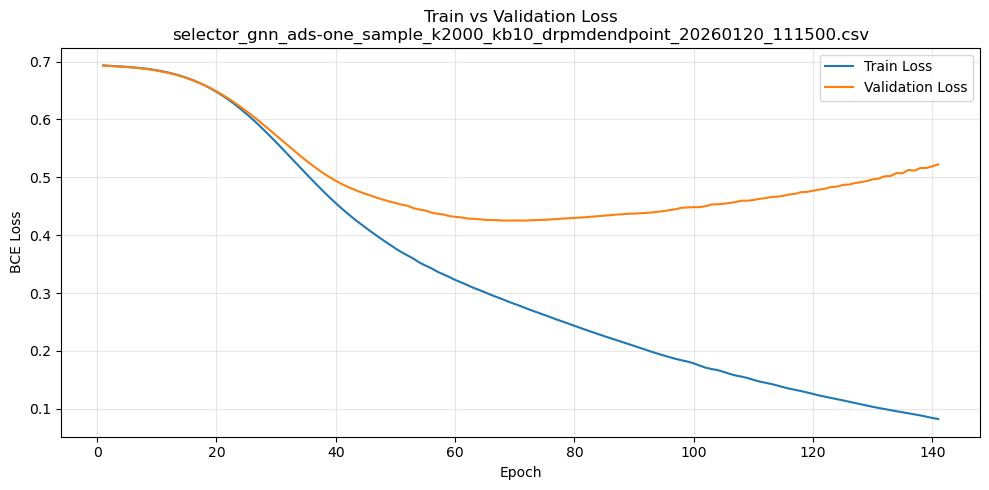

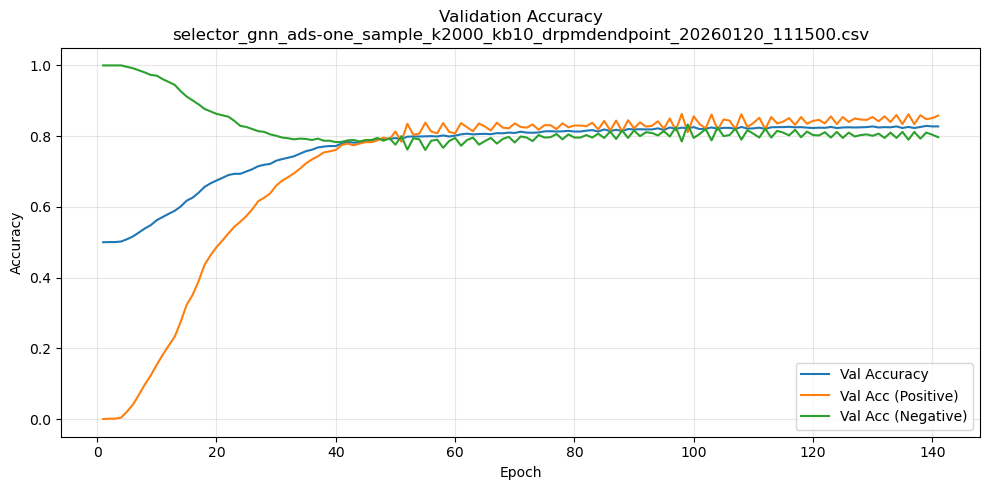

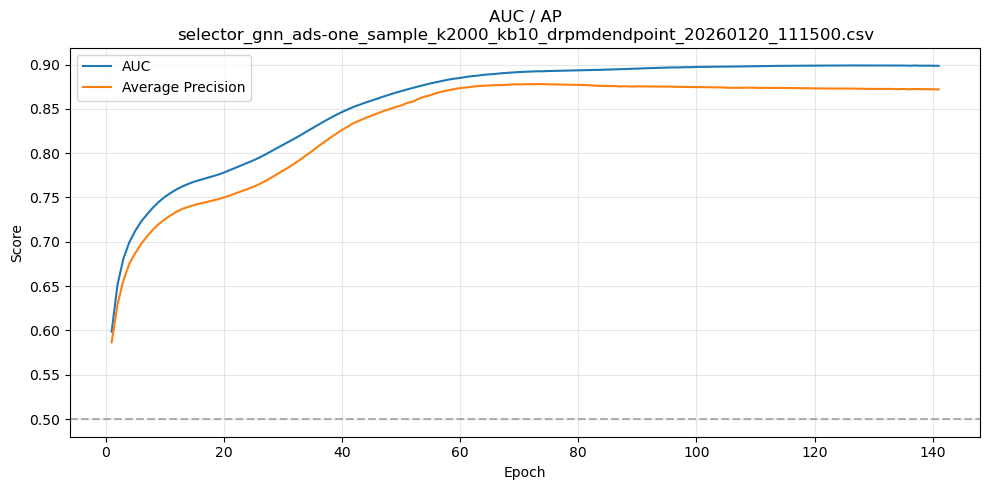

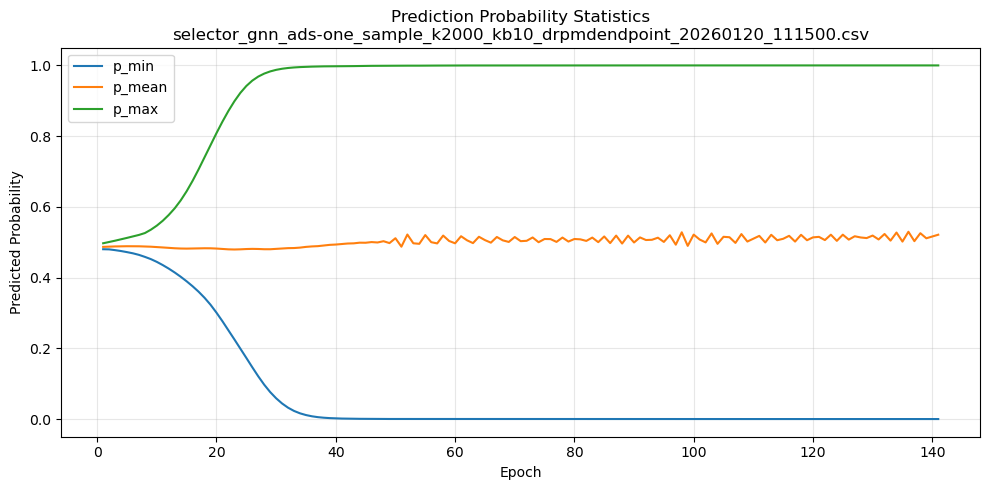

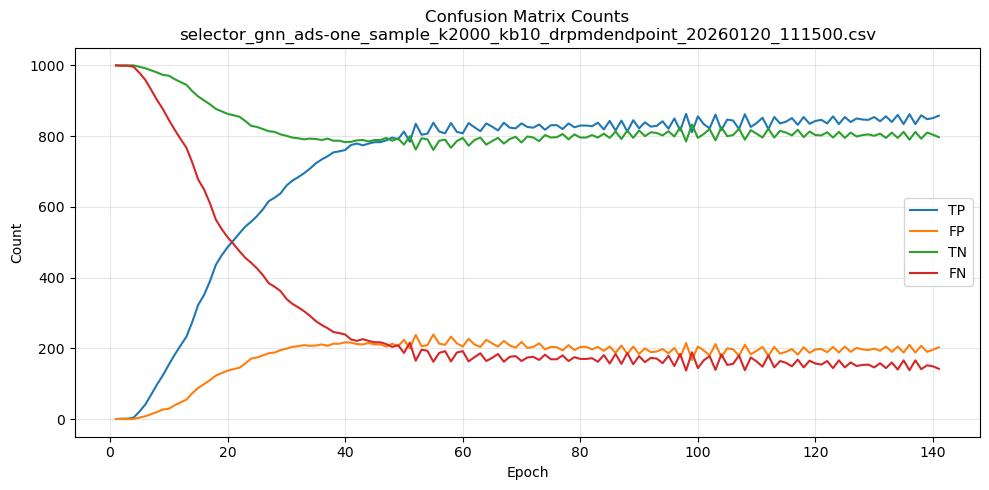

————————————————————————————————————————————————————————————


In [14]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# ===============================
# Folder with SelectorGNN CSVs
# ===============================
csv_folder = "Plotting_Data/SelectorGNNLogs"

csv_files = sorted([
    os.path.join(csv_folder, f)
    for f in os.listdir(csv_folder)
    if f.endswith(".csv")
])

if not csv_files:
    raise FileNotFoundError(f"No CSV files found in {csv_folder}")

print(f"Found {len(csv_files)} CSV files.\n")


for csv_path in csv_files:
    print(f" Plotting: {os.path.basename(csv_path)}")

    df = pd.read_csv(csv_path)

    # --- basic cleanup ---
    if "epoch" not in df.columns:
        print(" Skipping (no 'epoch' column found)")
        continue

    df["epoch"] = pd.to_numeric(df["epoch"], errors="coerce")
    df = df.dropna(subset=["epoch"])

    # ===============================
    # 1) Train vs Validation Loss
    # ===============================
    plt.figure(figsize=(10, 5))
    plt.plot(df["epoch"], df["train_loss"], label="Train Loss")
    plt.plot(df["epoch"], df["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("BCE Loss")
    plt.title(f"Train vs Validation Loss\n{os.path.basename(csv_path)}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # ===============================
    # 2) Validation Accuracy (overall + per class)
    # ===============================
    plt.figure(figsize=(10, 5))
    plt.plot(df["epoch"], df["val_acc"], label="Val Accuracy")
    plt.plot(df["epoch"], df["acc_pos"], label="Val Acc (Positive)")
    plt.plot(df["epoch"], df["acc_neg"], label="Val Acc (Negative)")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"Validation Accuracy\n{os.path.basename(csv_path)}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # ===============================
    # 3) AUC & Average Precision
    # ===============================
    if "auc" in df.columns and "ap" in df.columns:
        plt.figure(figsize=(10, 5))
        plt.plot(df["epoch"], df["auc"], label="AUC")
        plt.plot(df["epoch"], df["ap"], label="Average Precision")
        plt.axhline(0.5, linestyle="--", color="gray", alpha=0.6)
        plt.xlabel("Epoch")
        plt.ylabel("Score")
        plt.title(f"AUC / AP\n{os.path.basename(csv_path)}")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

    # ===============================
    # 4) Prediction probability stats
    # ===============================
    plt.figure(figsize=(10, 5))
    plt.plot(df["epoch"], df["p_min"], label="p_min")
    plt.plot(df["epoch"], df["p_mean"], label="p_mean")
    plt.plot(df["epoch"], df["p_max"], label="p_max")
    plt.xlabel("Epoch")
    plt.ylabel("Predicted Probability")
    plt.title(f"Prediction Probability Statistics\n{os.path.basename(csv_path)}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # ===============================
    # 5) Confusion matrix evolution
    # ===============================
    plt.figure(figsize=(10, 5))
    plt.plot(df["epoch"], df["tp"], label="TP")
    plt.plot(df["epoch"], df["fp"], label="FP")
    plt.plot(df["epoch"], df["tn"], label="TN")
    plt.plot(df["epoch"], df["fn"], label="FN")
    plt.xlabel("Epoch")
    plt.ylabel("Count")
    plt.title(f"Confusion Matrix Counts\n{os.path.basename(csv_path)}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # ===============================
    # 6) Gradient norm (optional)
    # ===============================
    if "grad_norm" in df.columns and df["grad_norm"].notna().any():
        plt.figure(figsize=(10, 5))
        plt.plot(df["epoch"], df["grad_norm"])
        plt.xlabel("Epoch")
        plt.ylabel("Gradient Norm")
        plt.title(f"Gradient Norm\n{os.path.basename(csv_path)}")
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

    print("—" * 60)

#### 2.2.1 PRBCD Logs

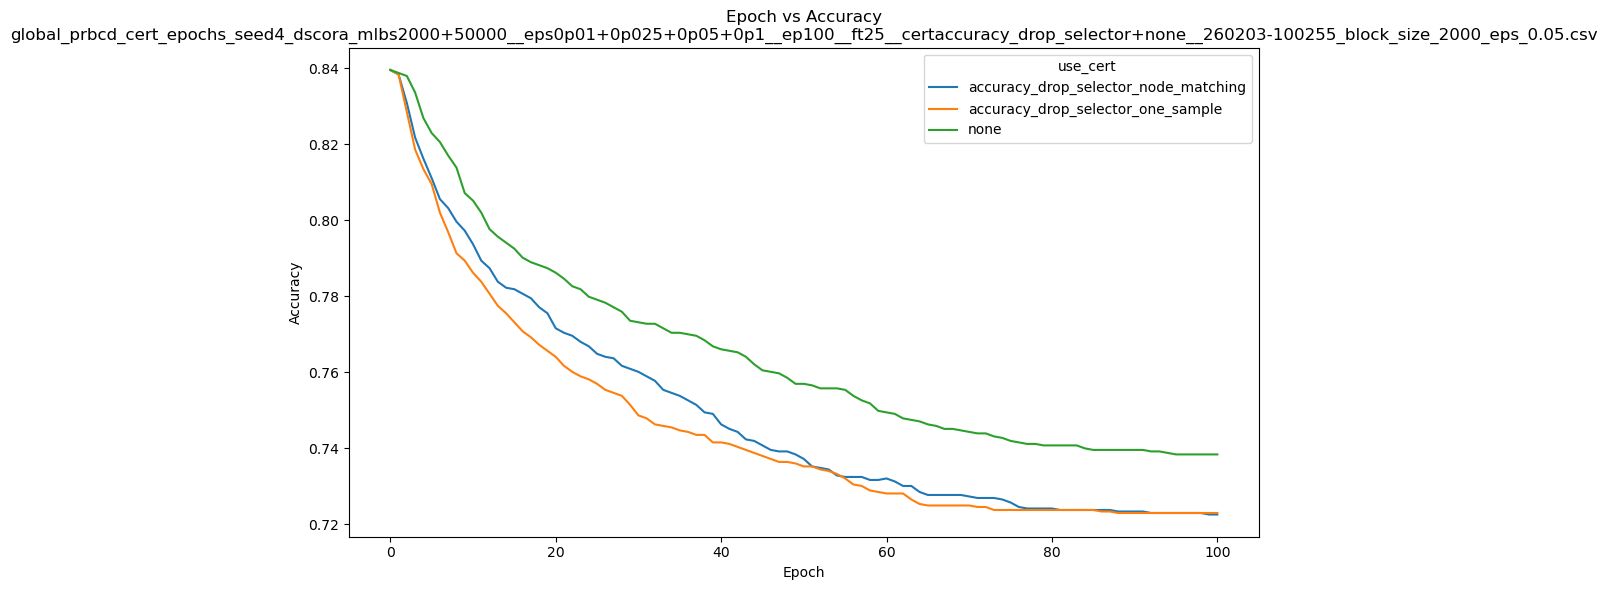

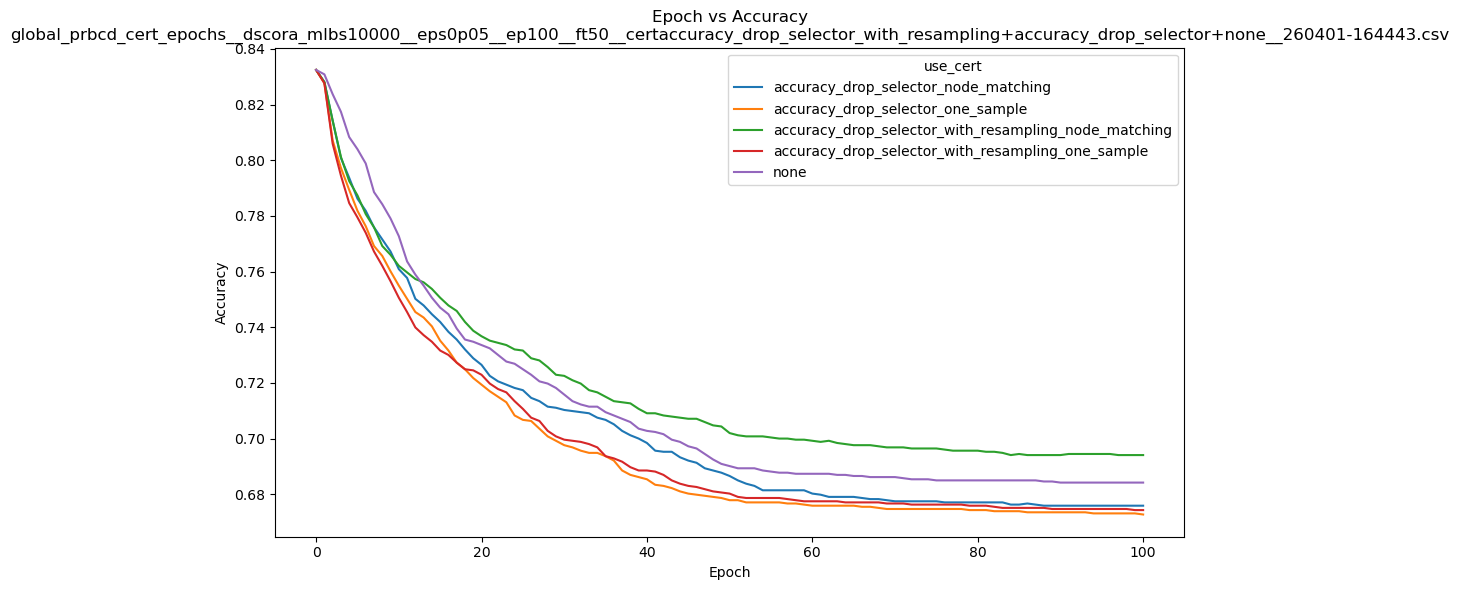

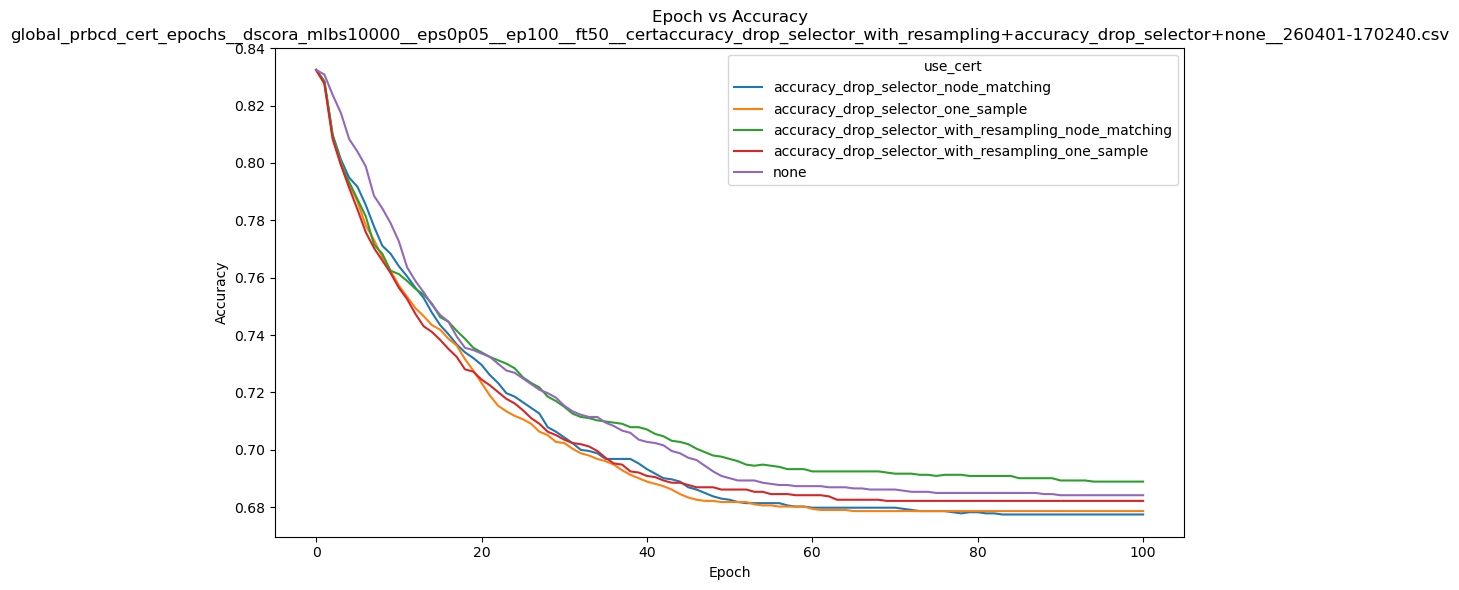

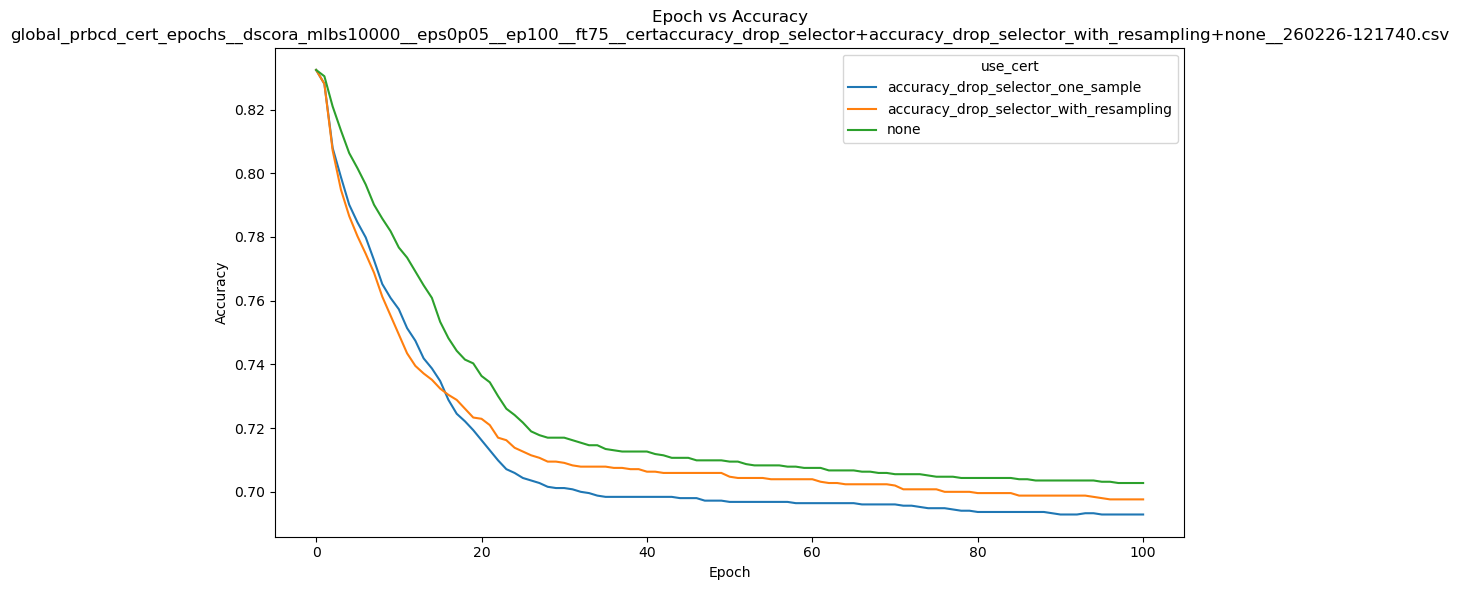

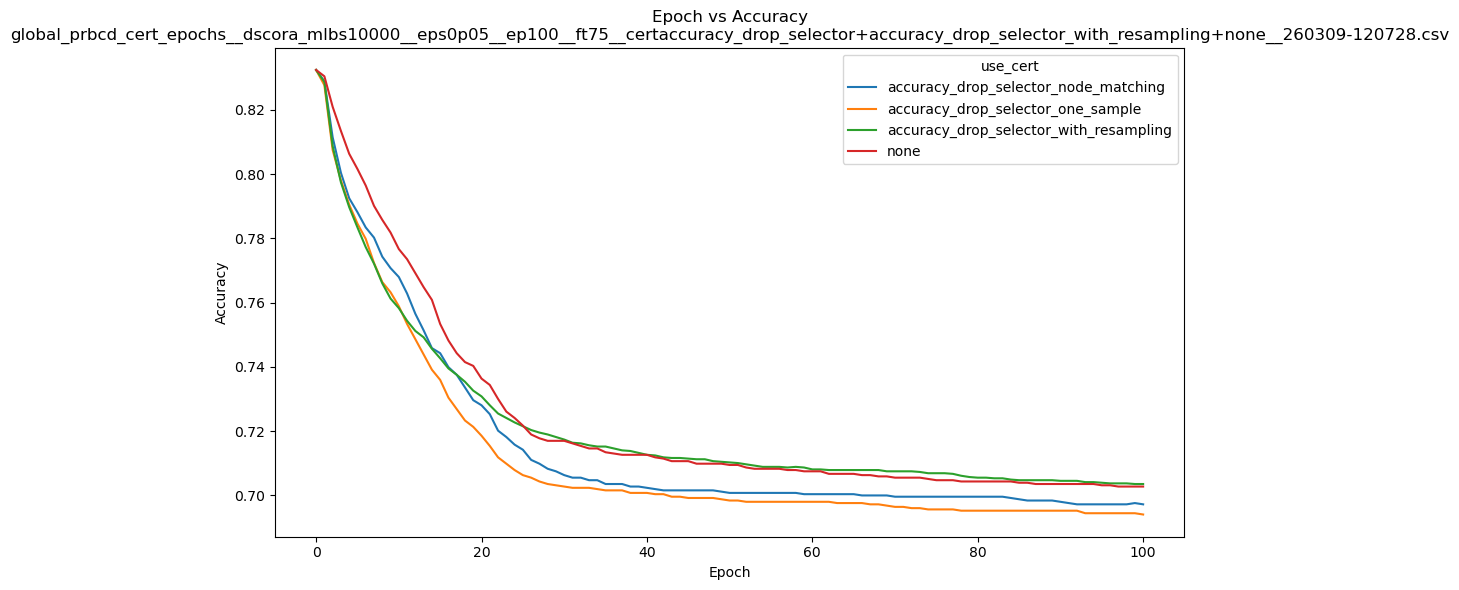

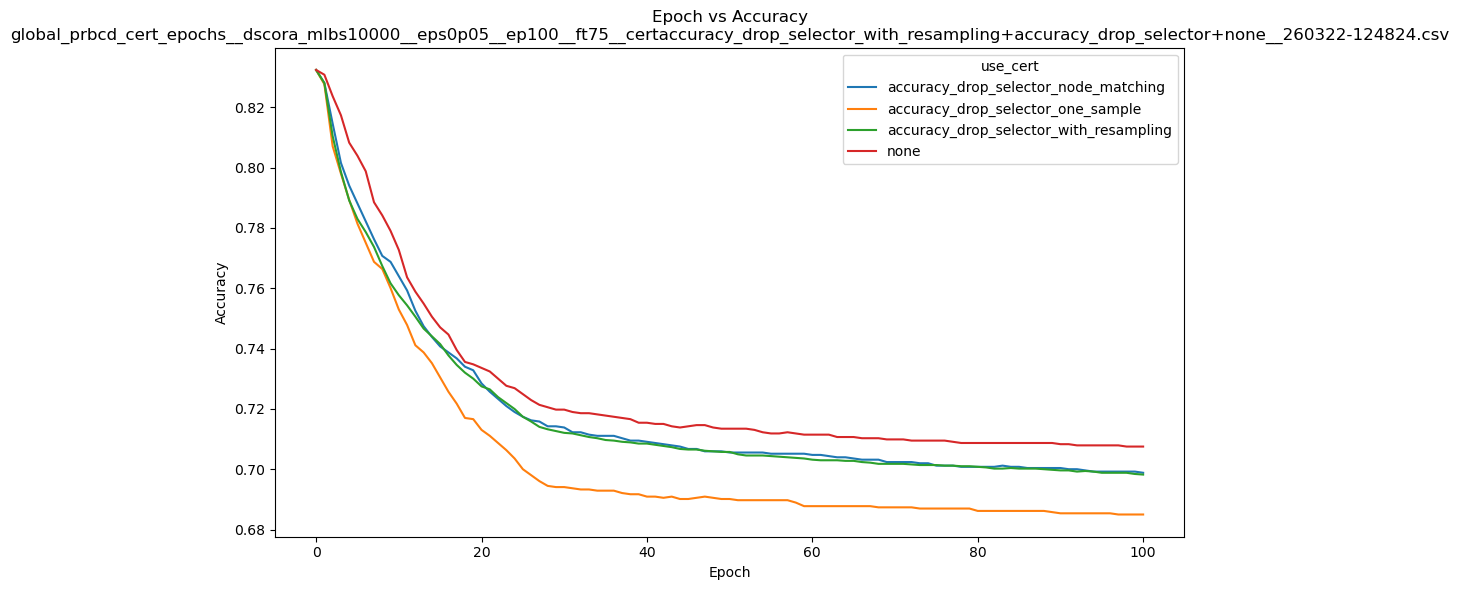

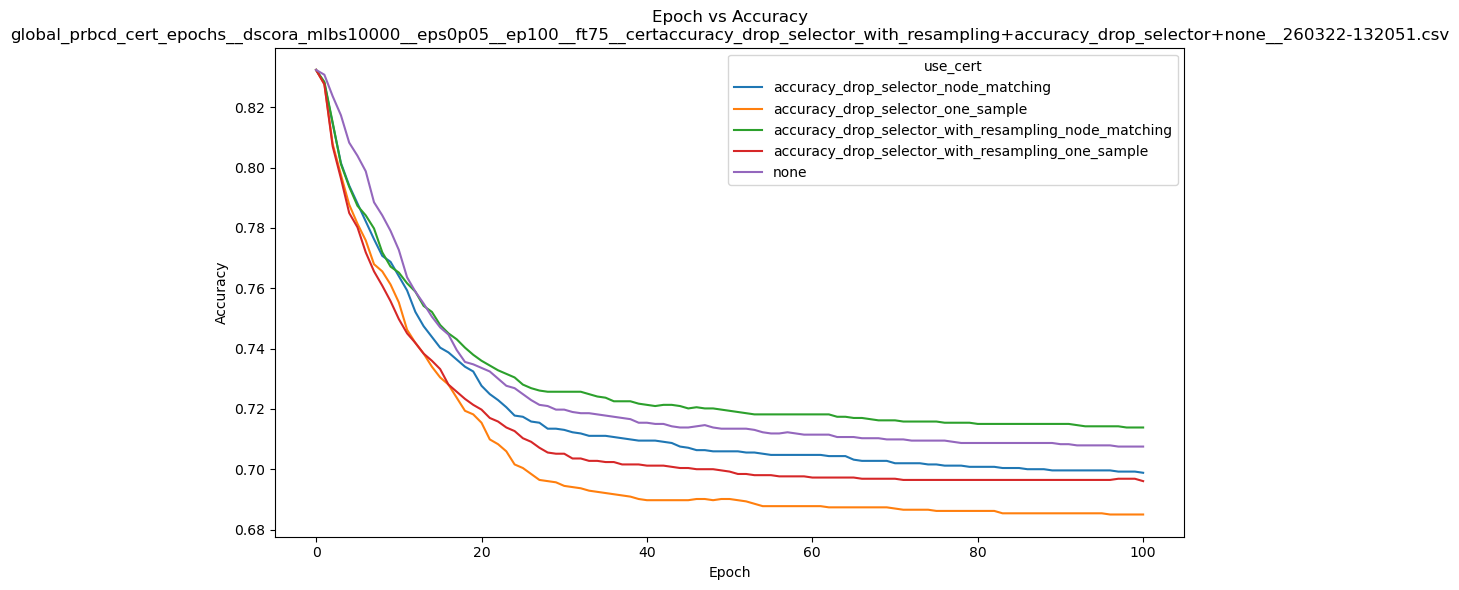

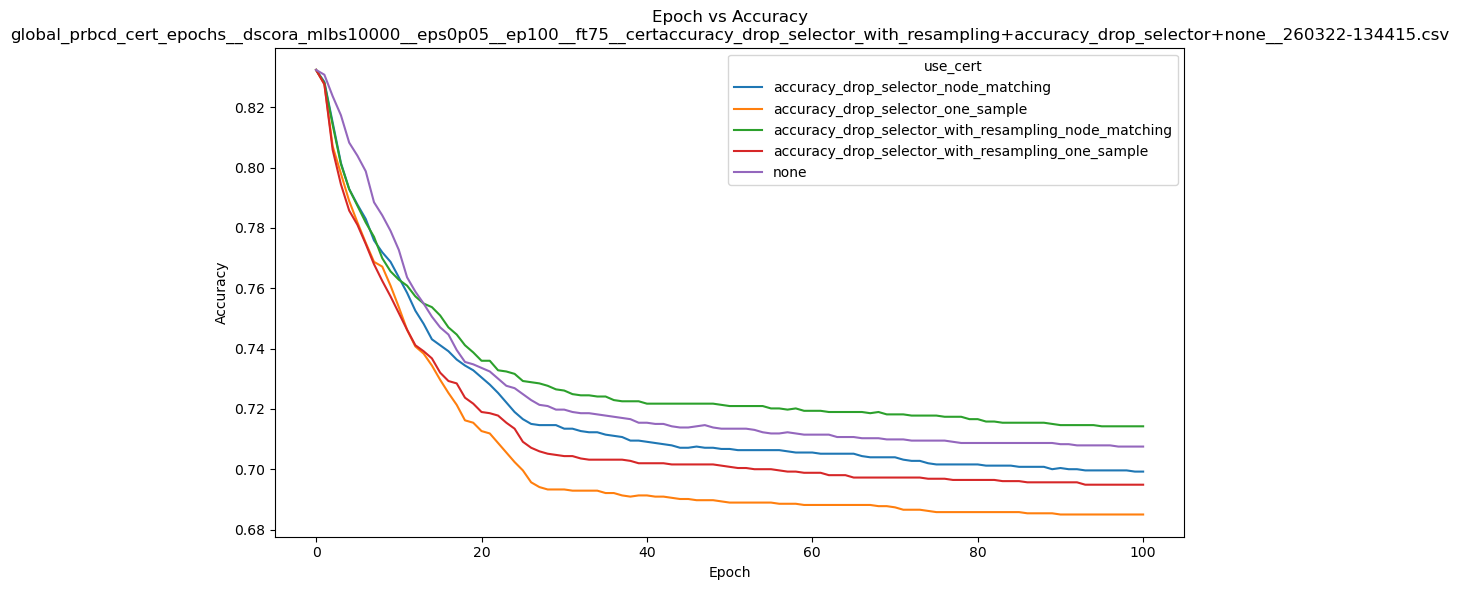

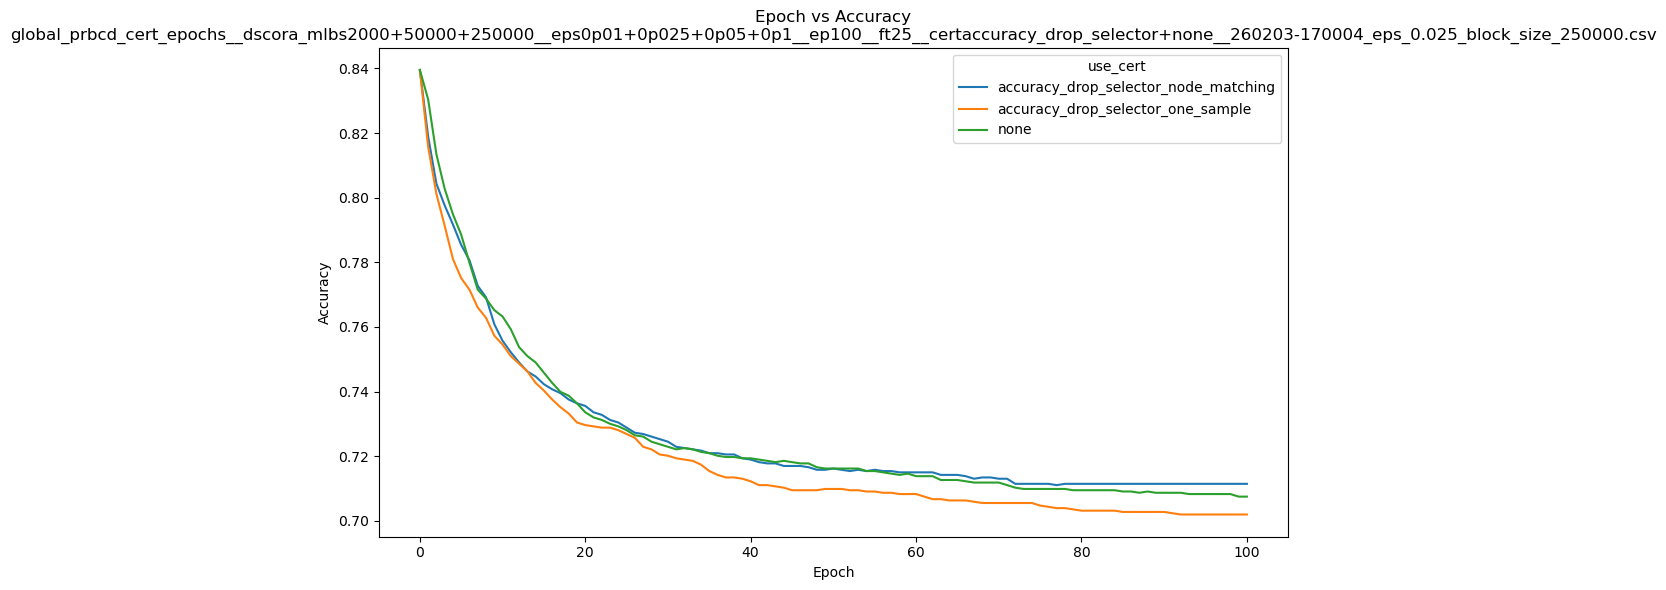

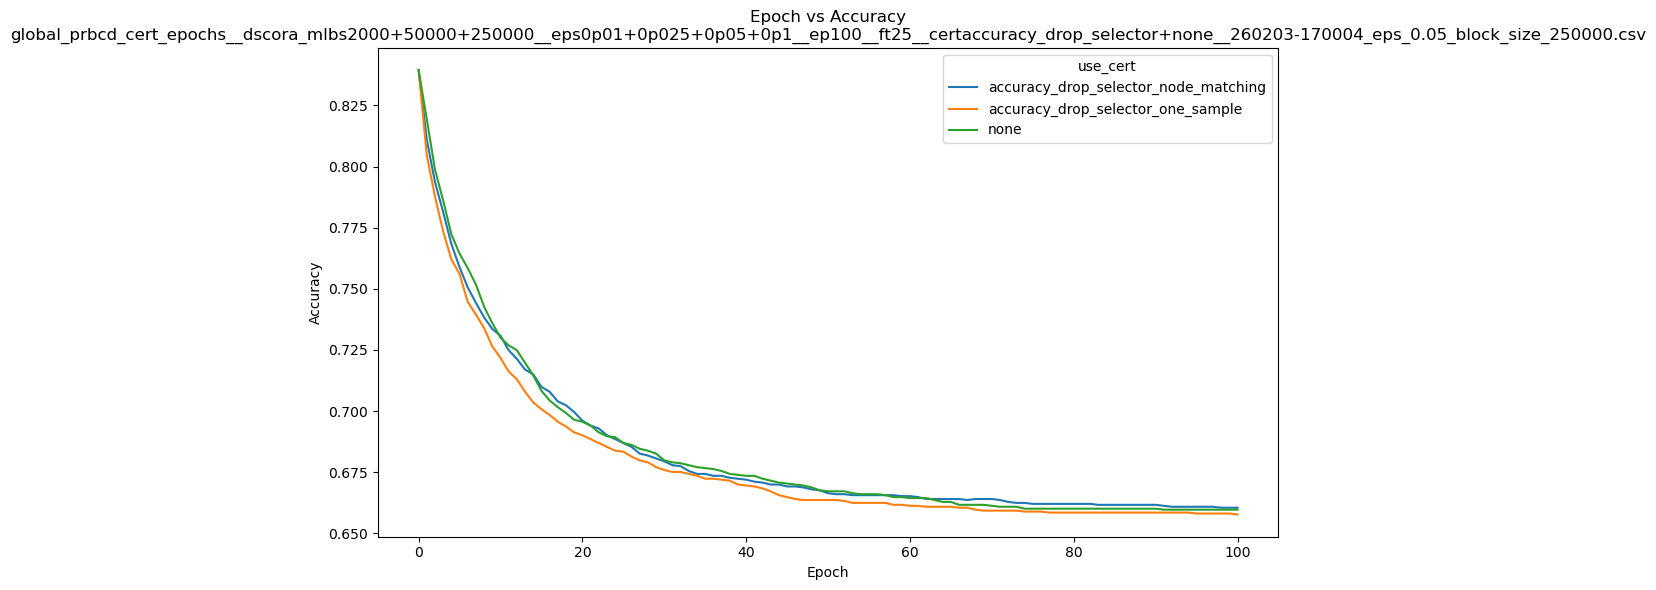

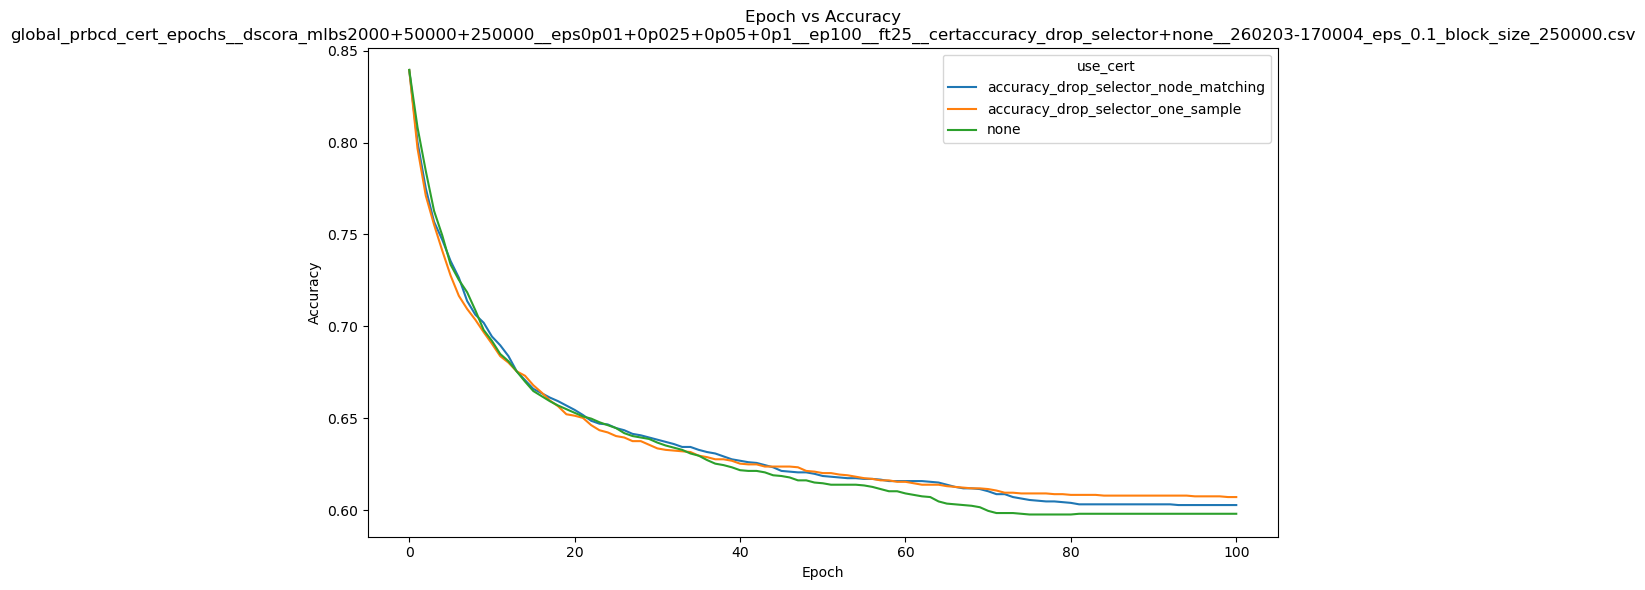

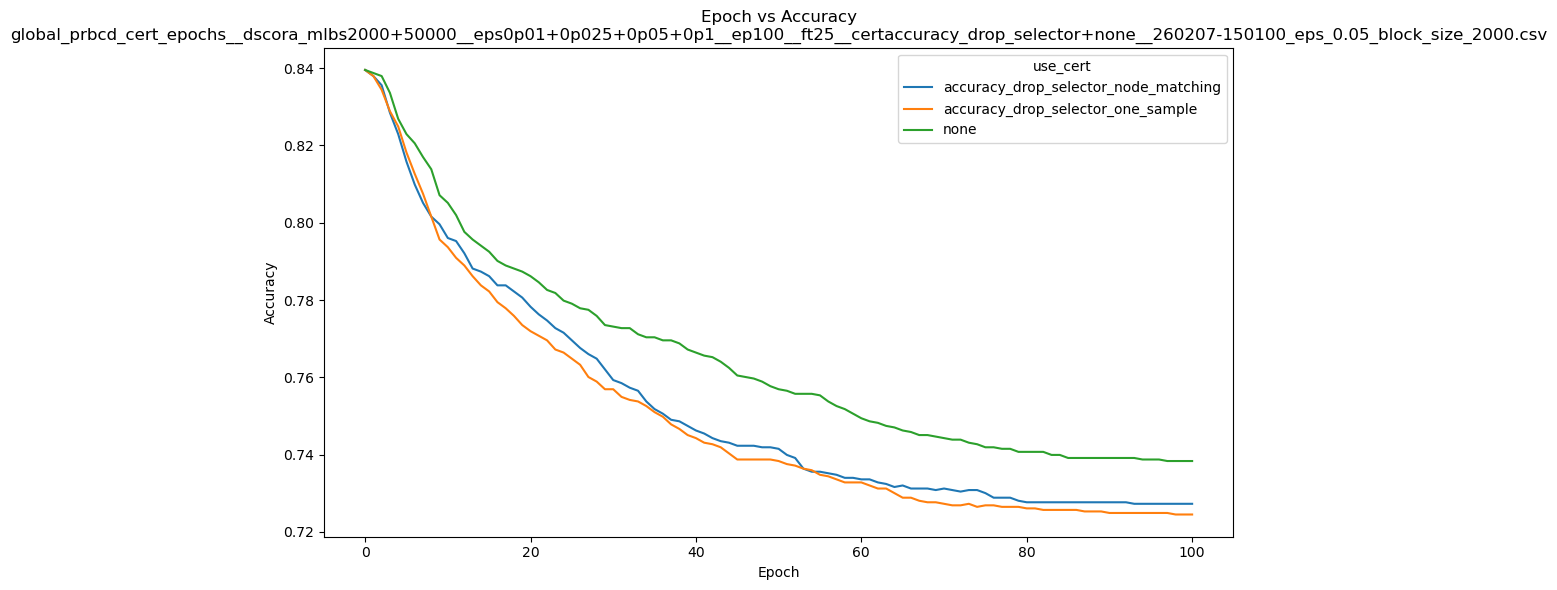

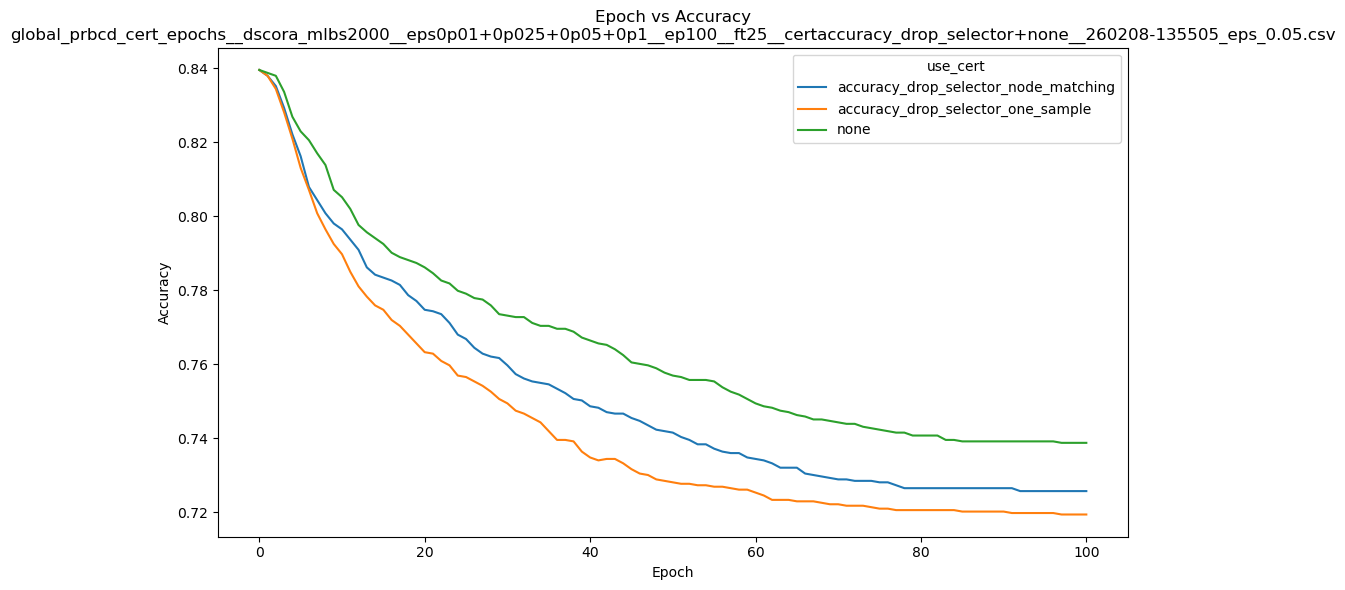

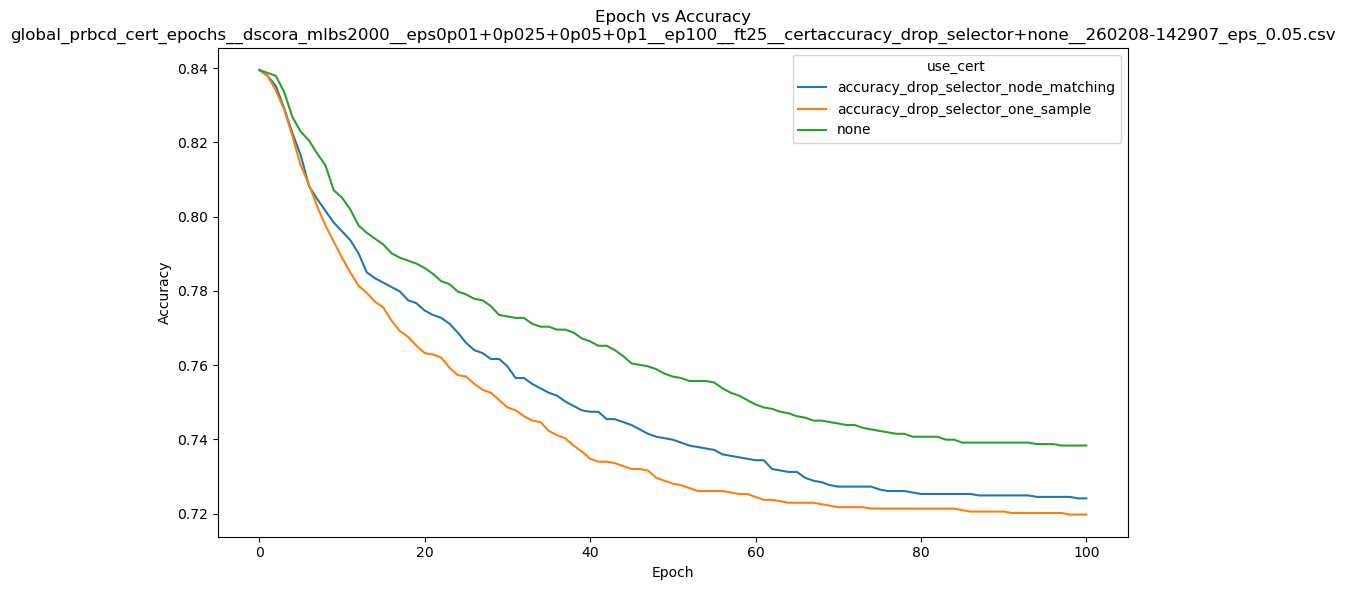

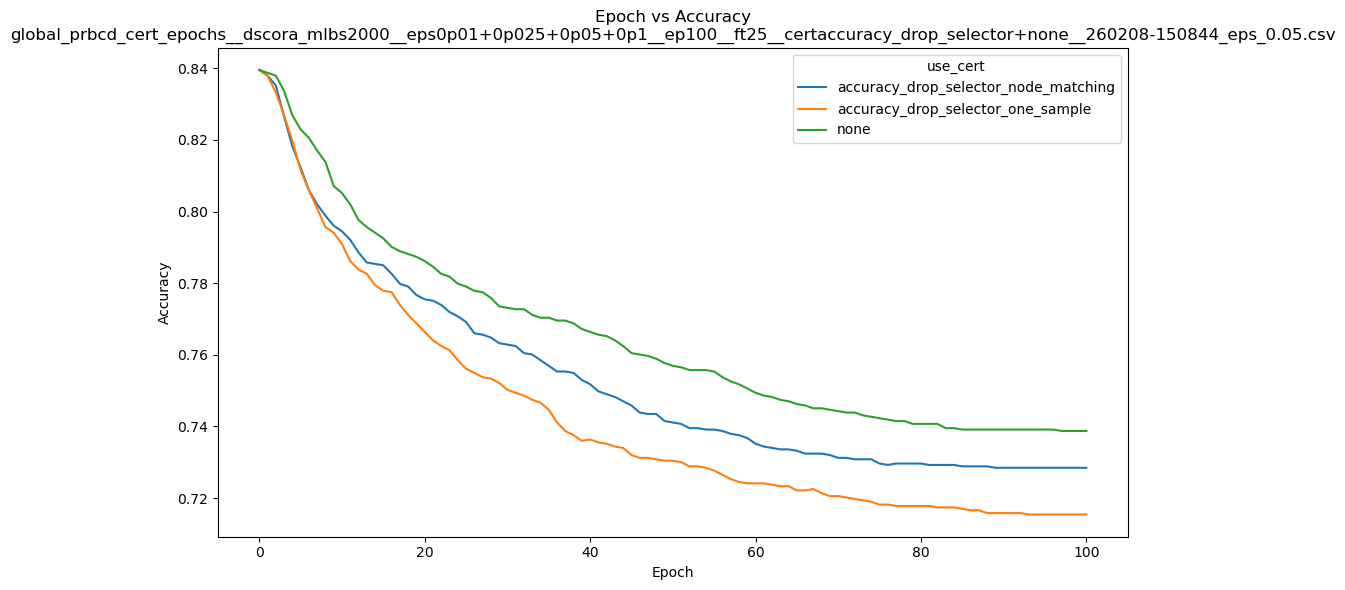

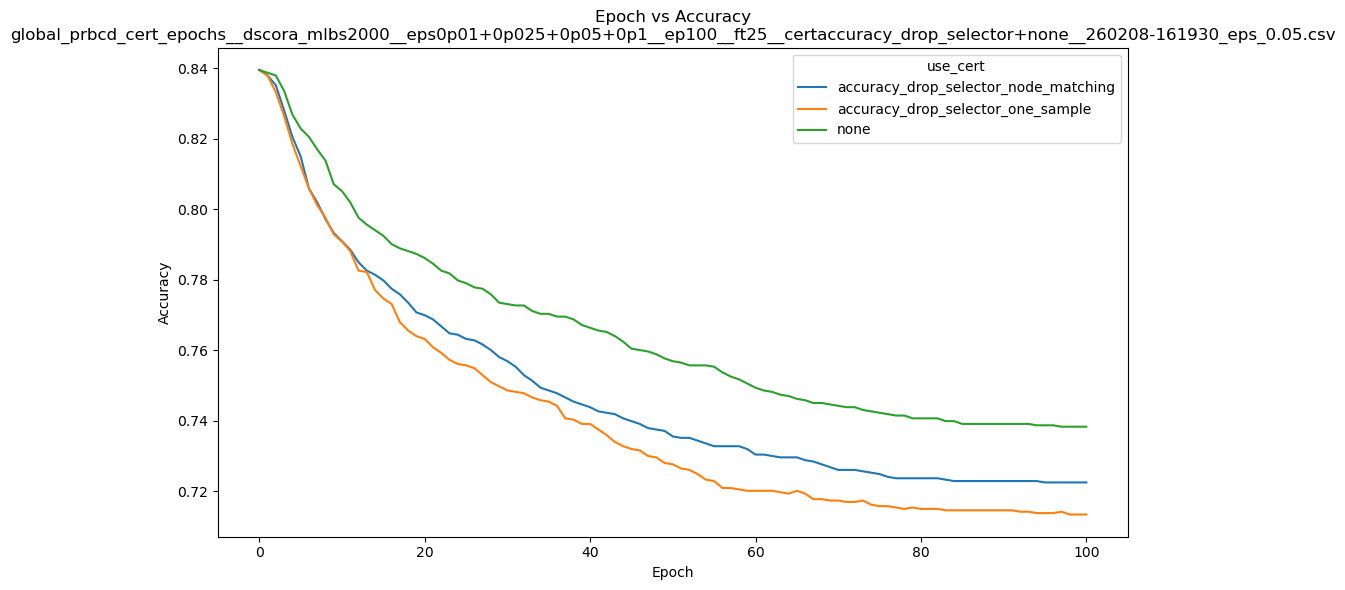

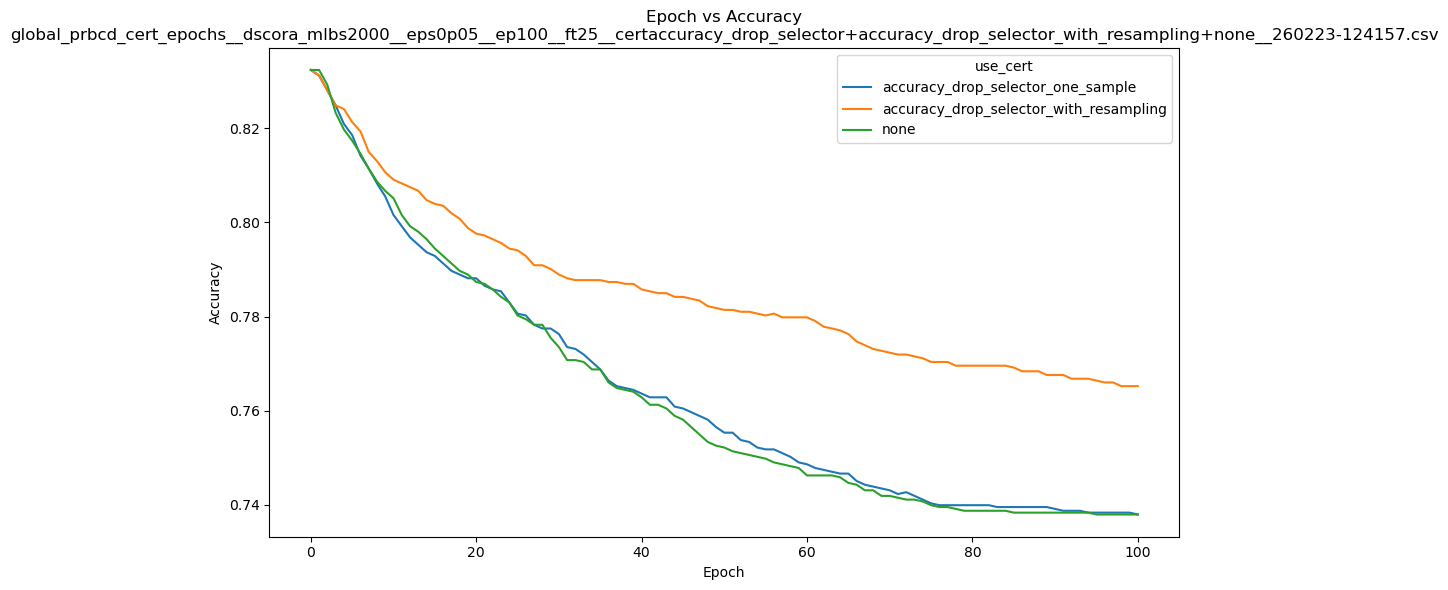

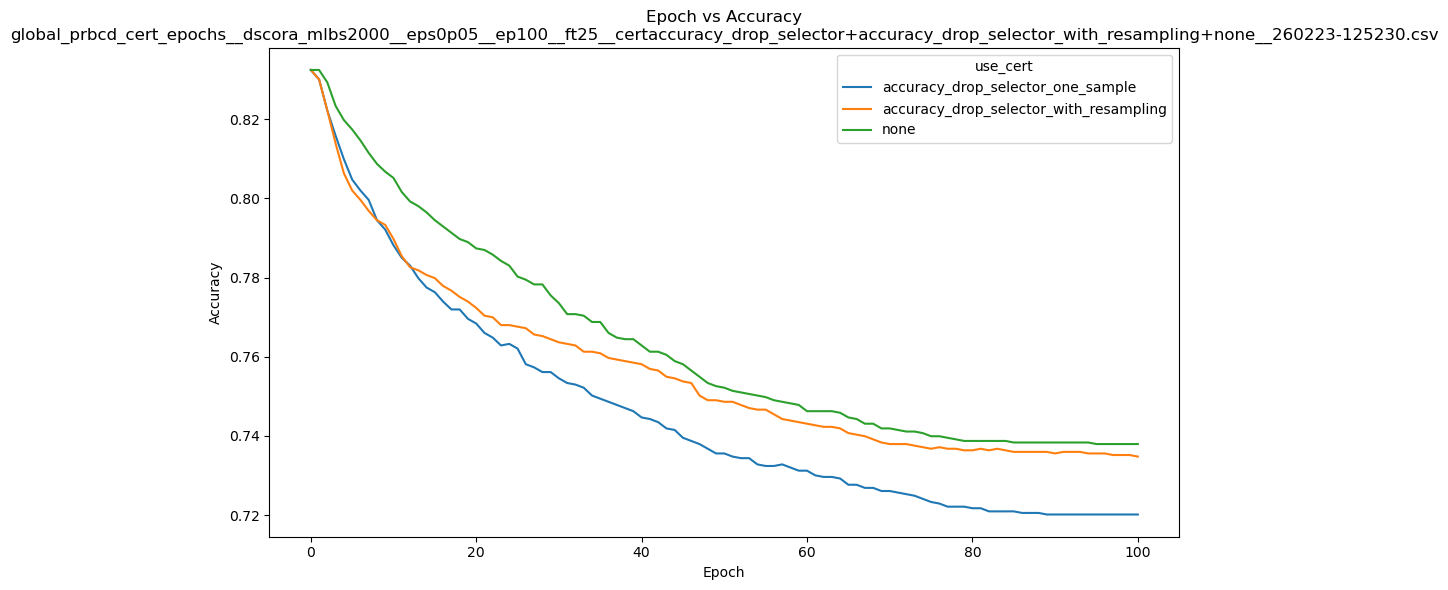

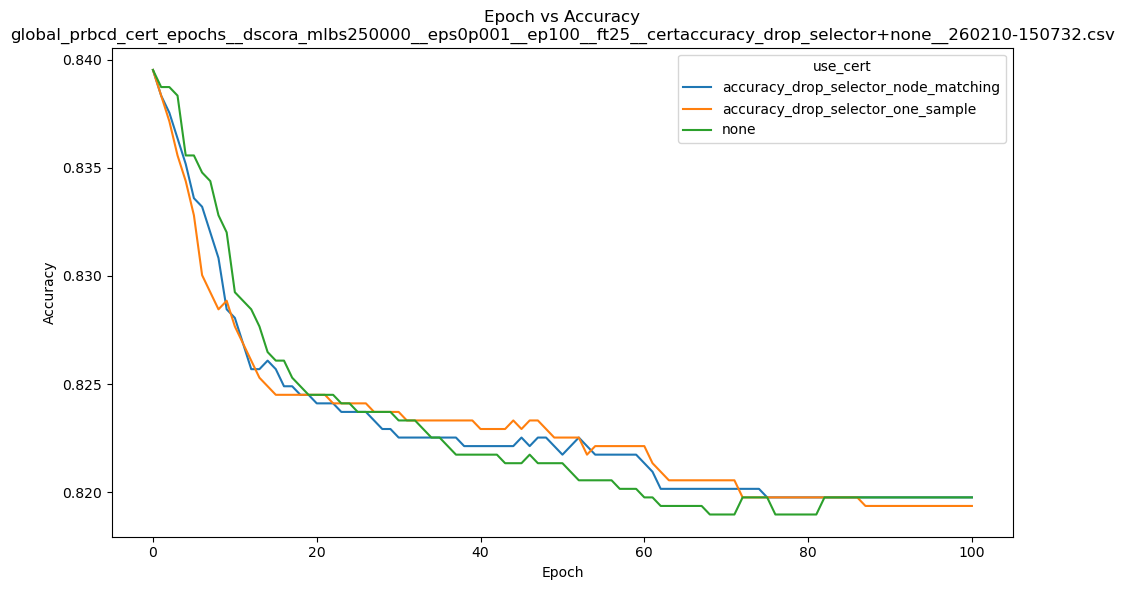

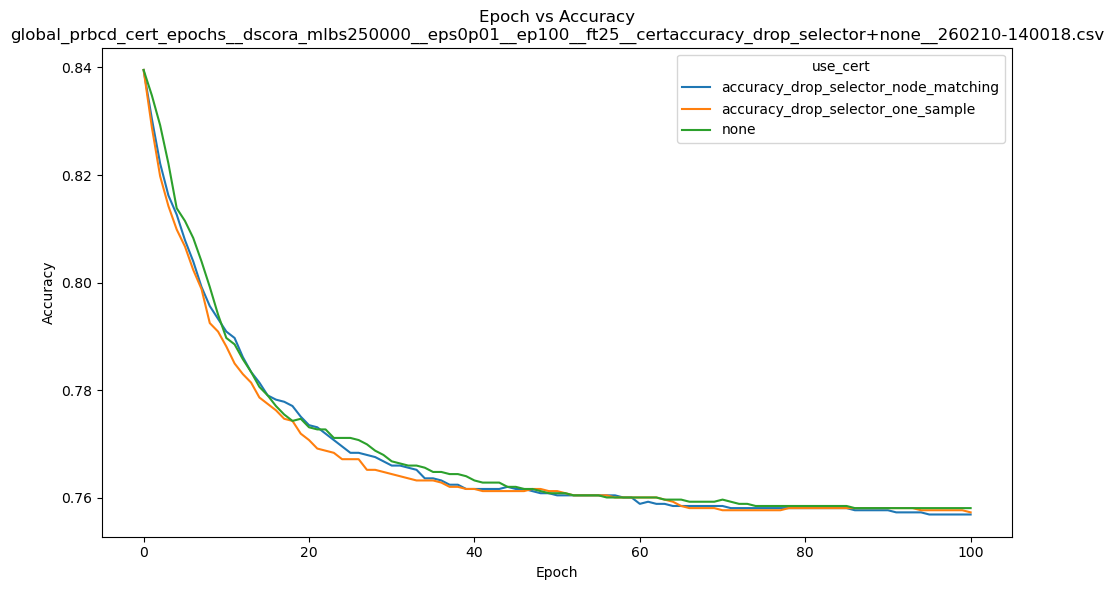

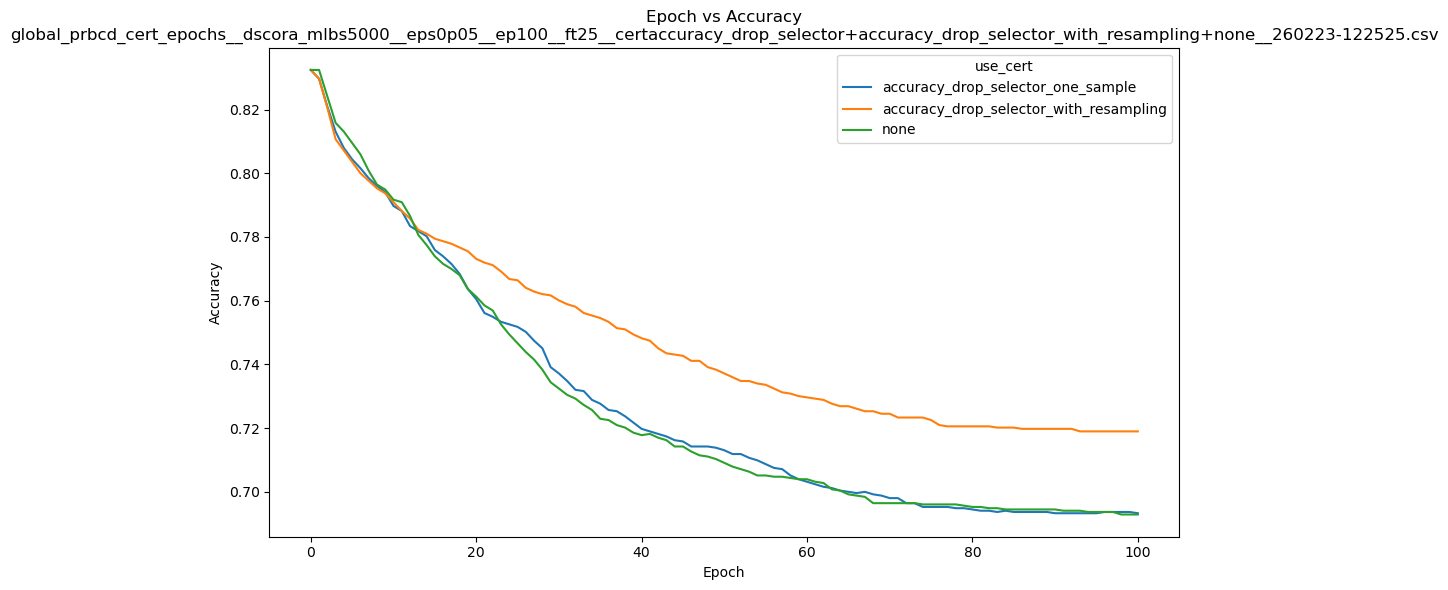

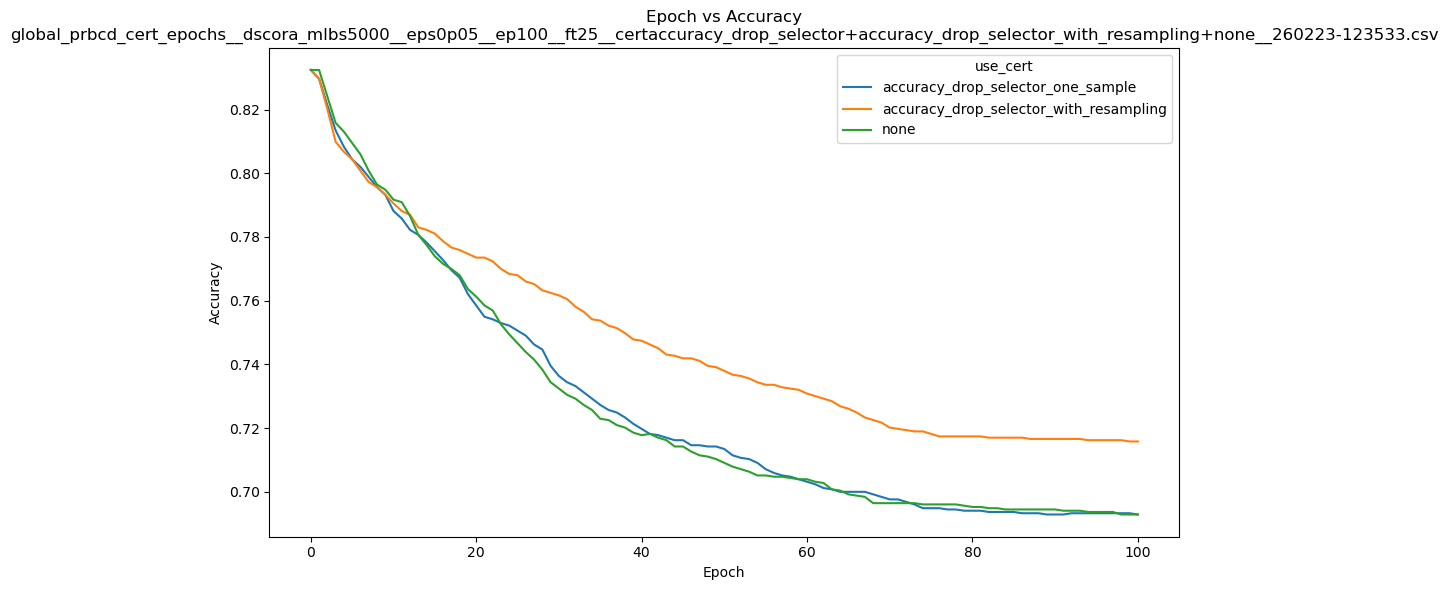

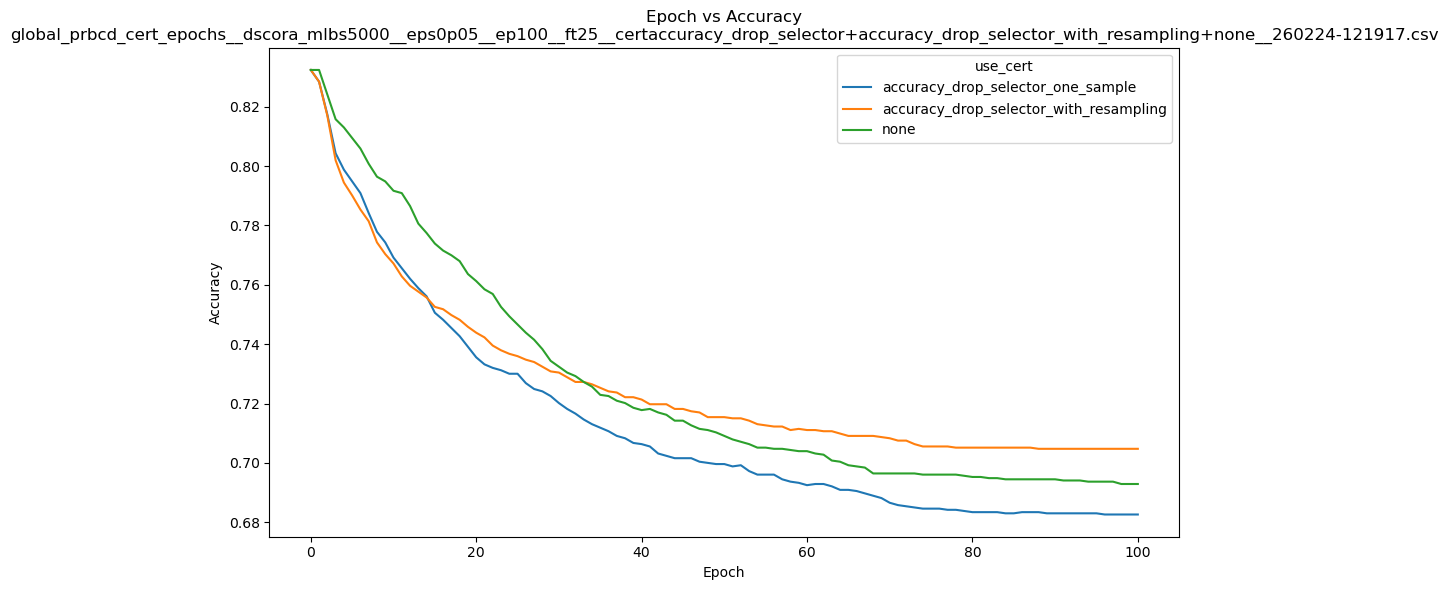

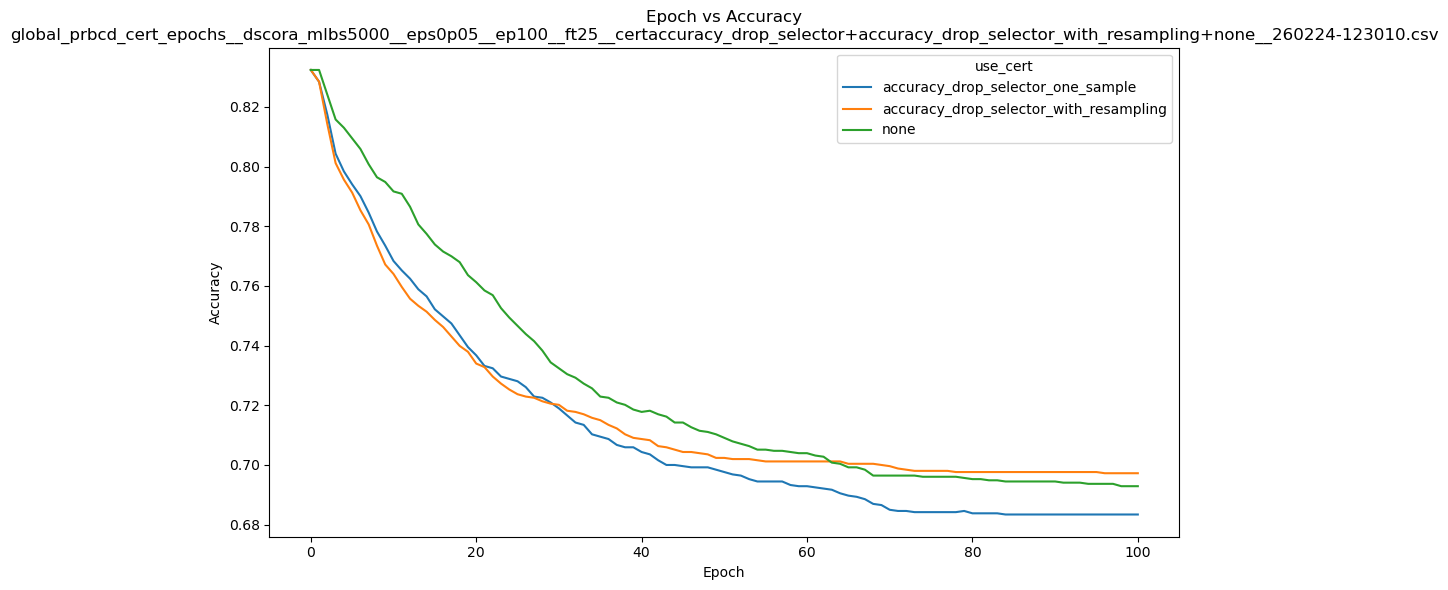

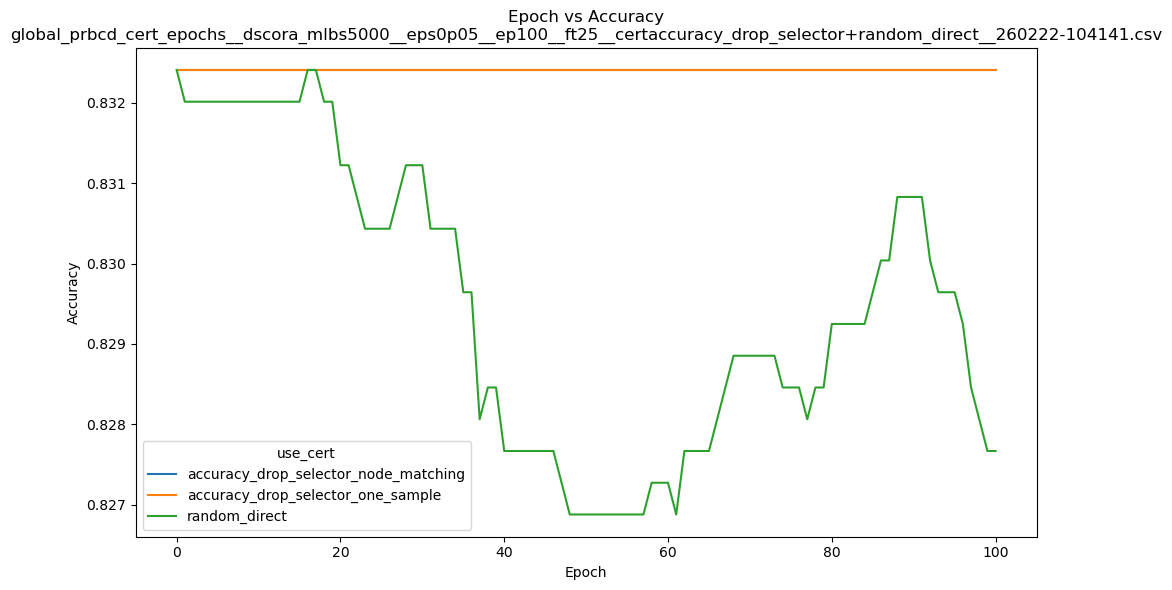

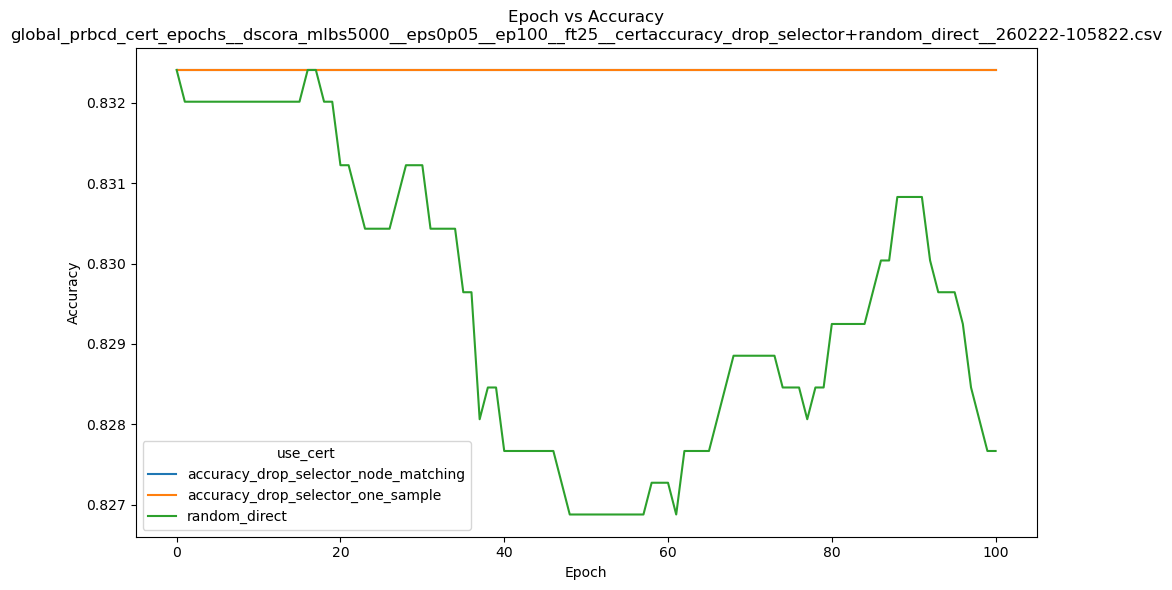

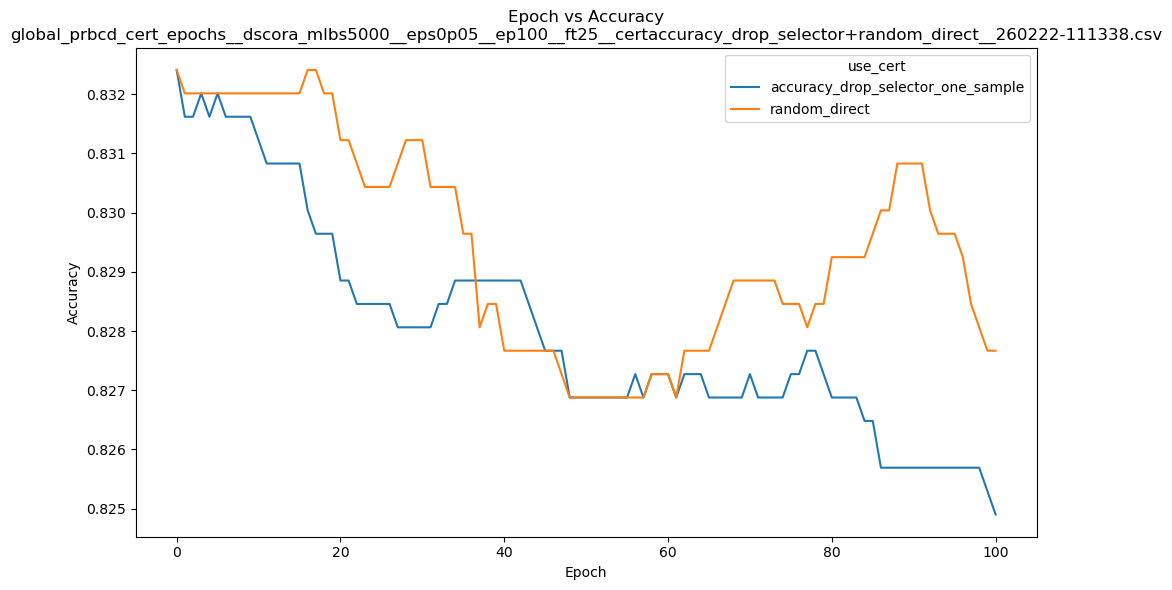

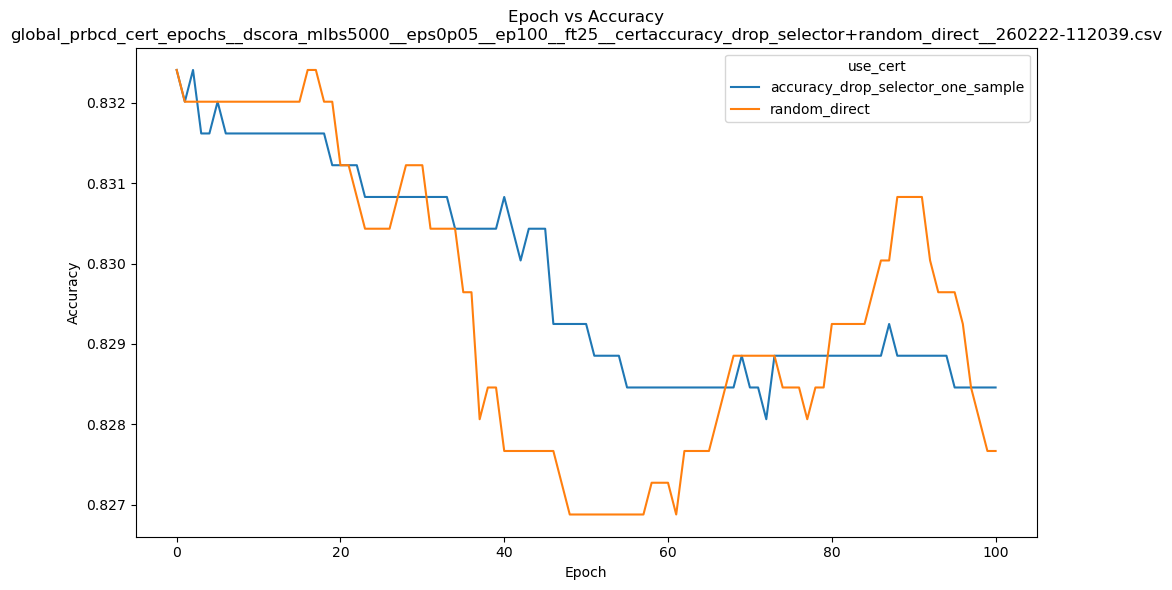

C:\Users\Schulz\AppData\Local\Temp\ipykernel_7212\2187971642.py:64: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=group_col)


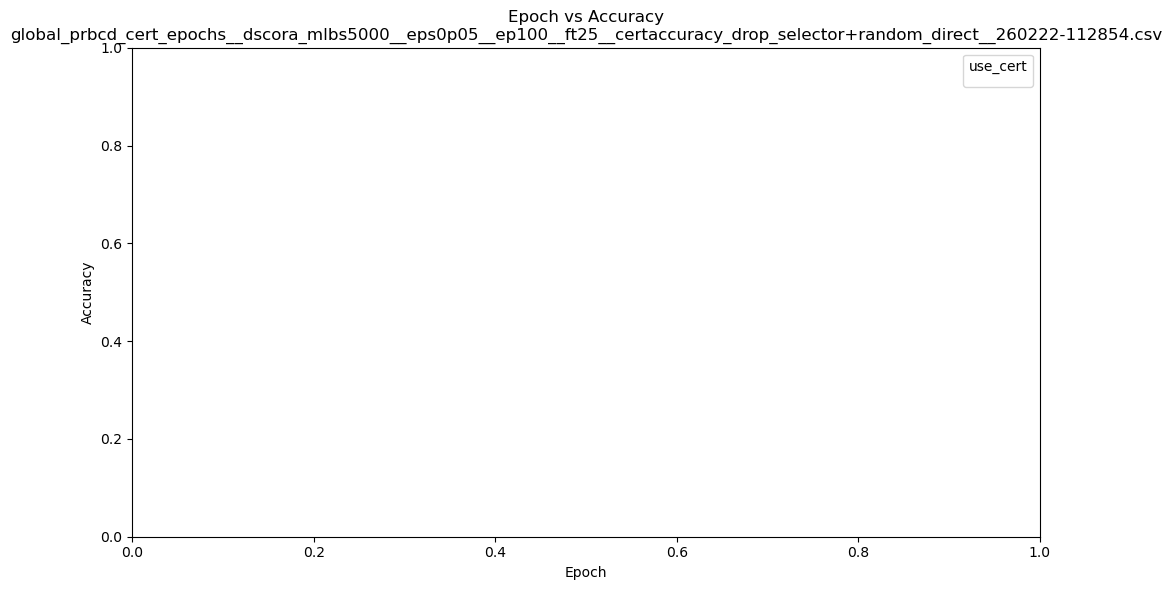

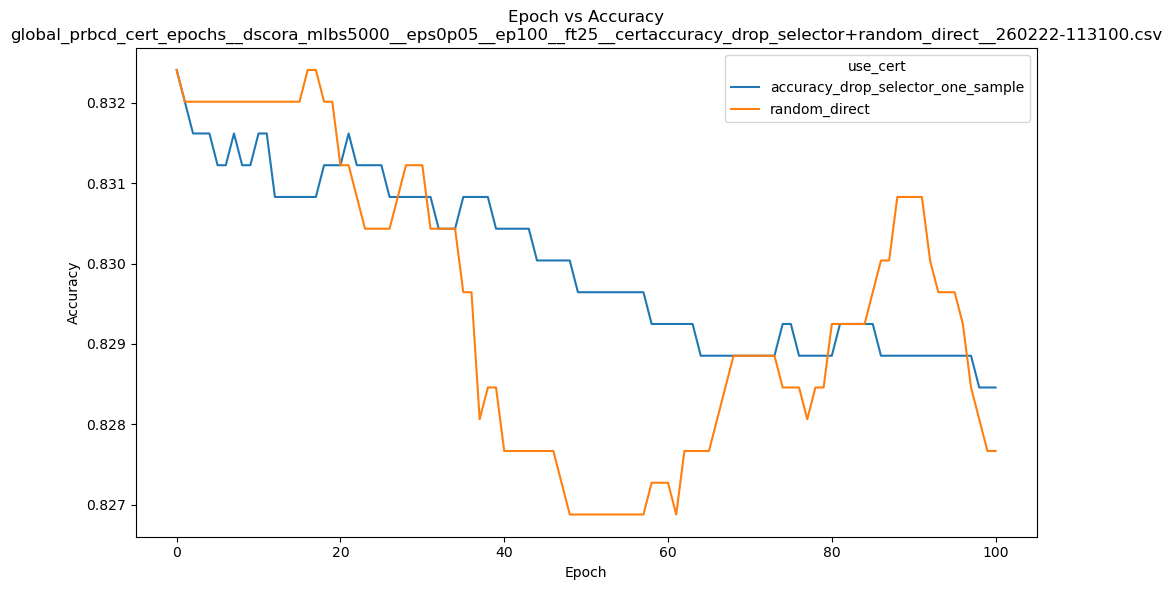

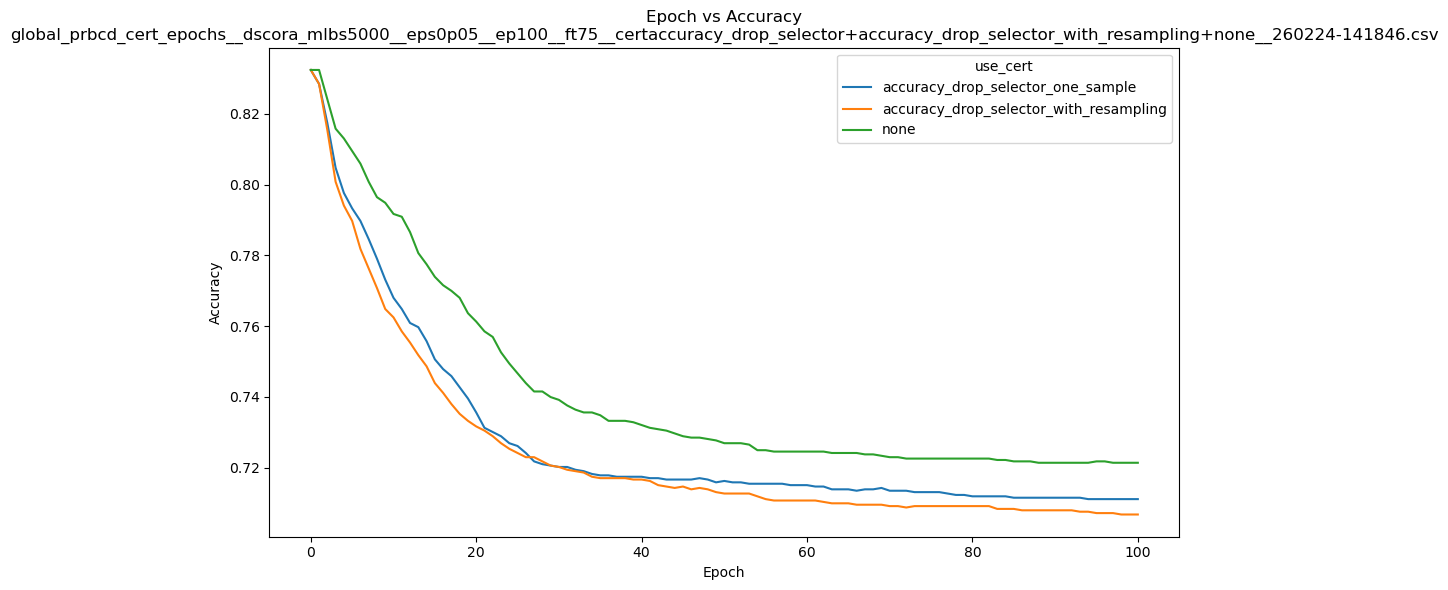

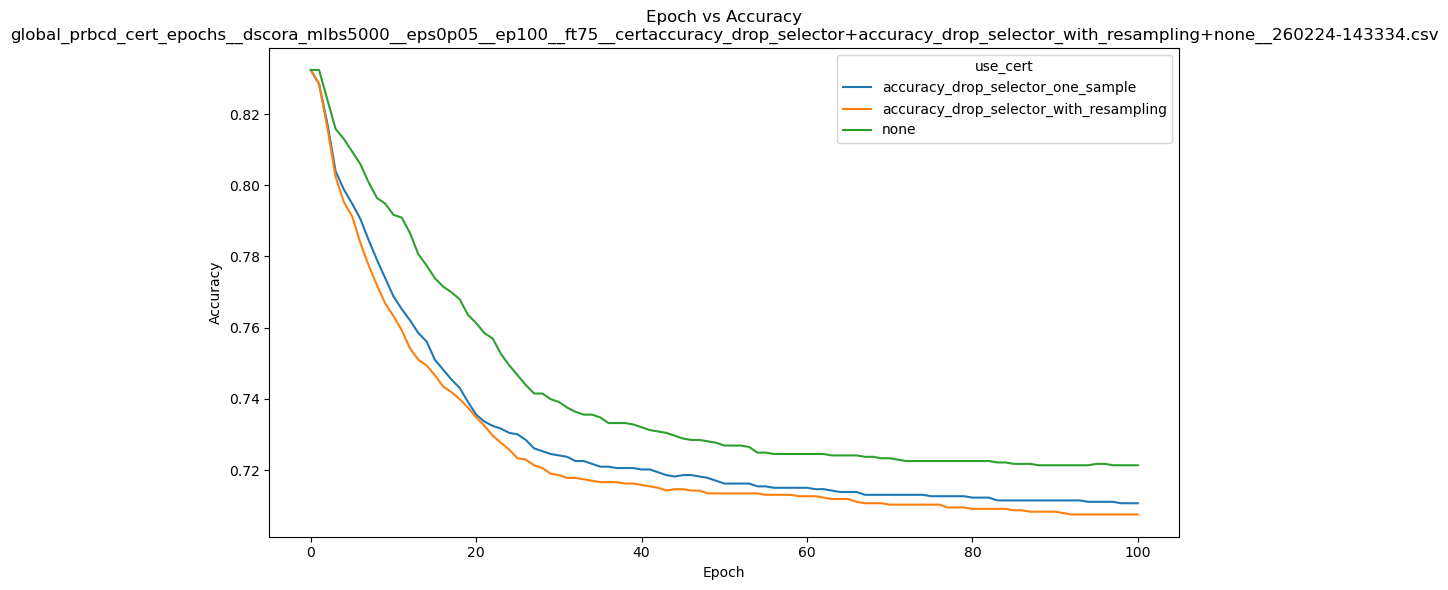

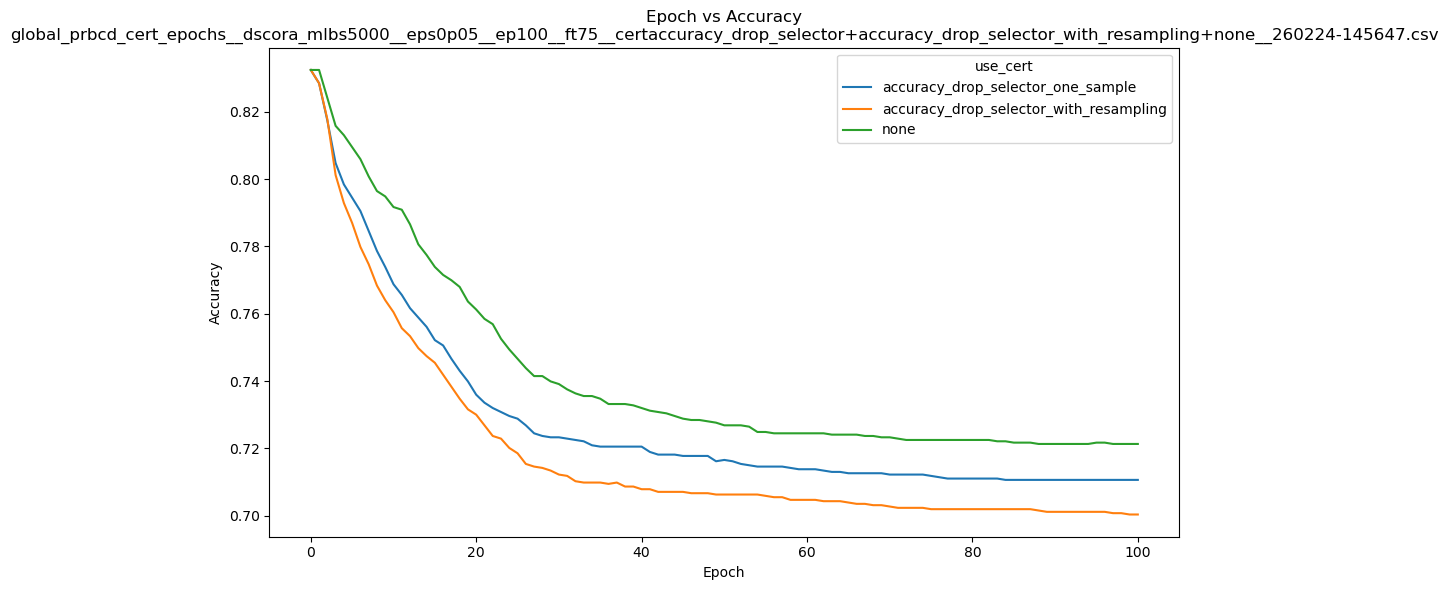

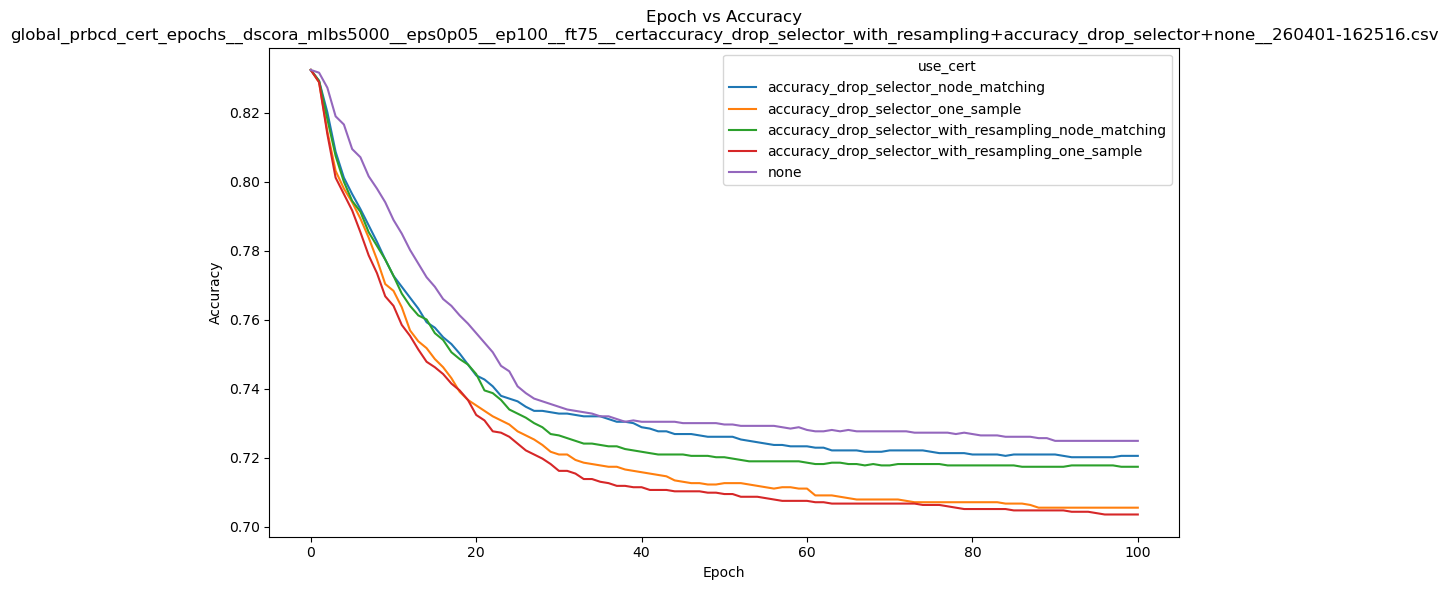

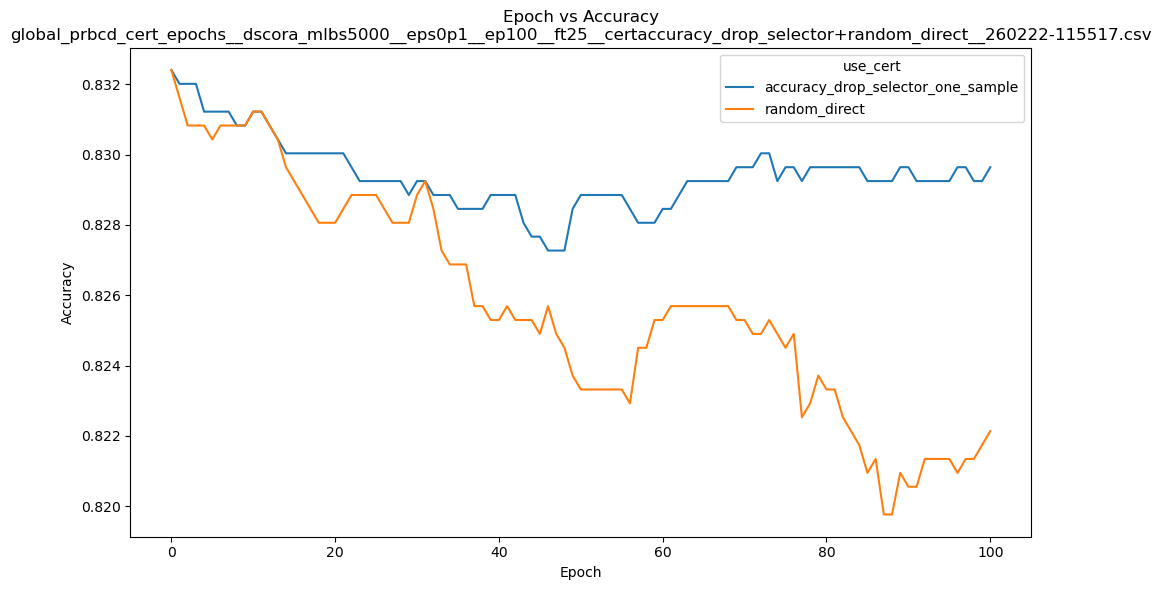

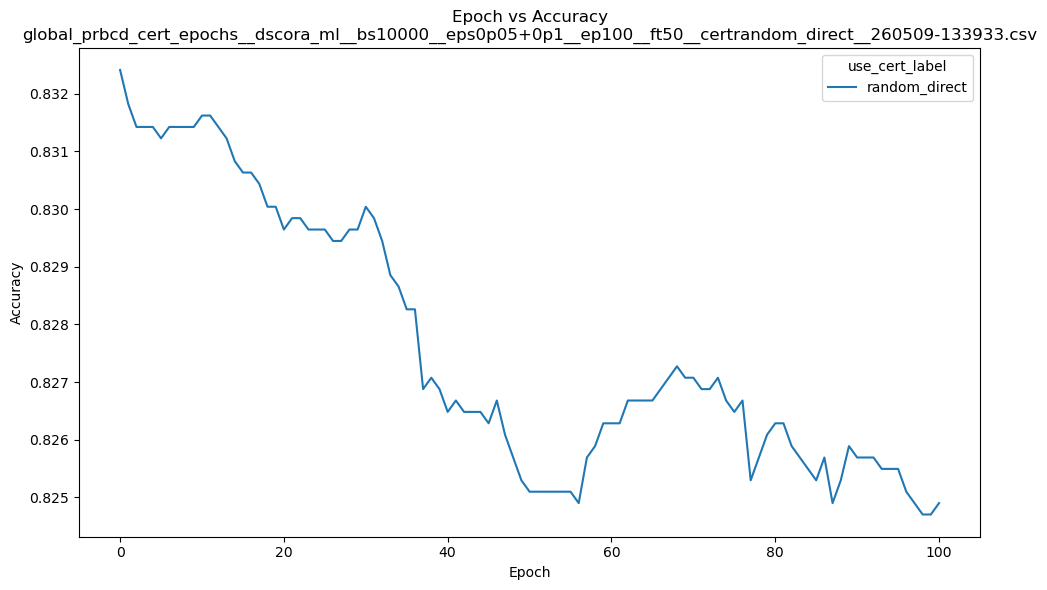

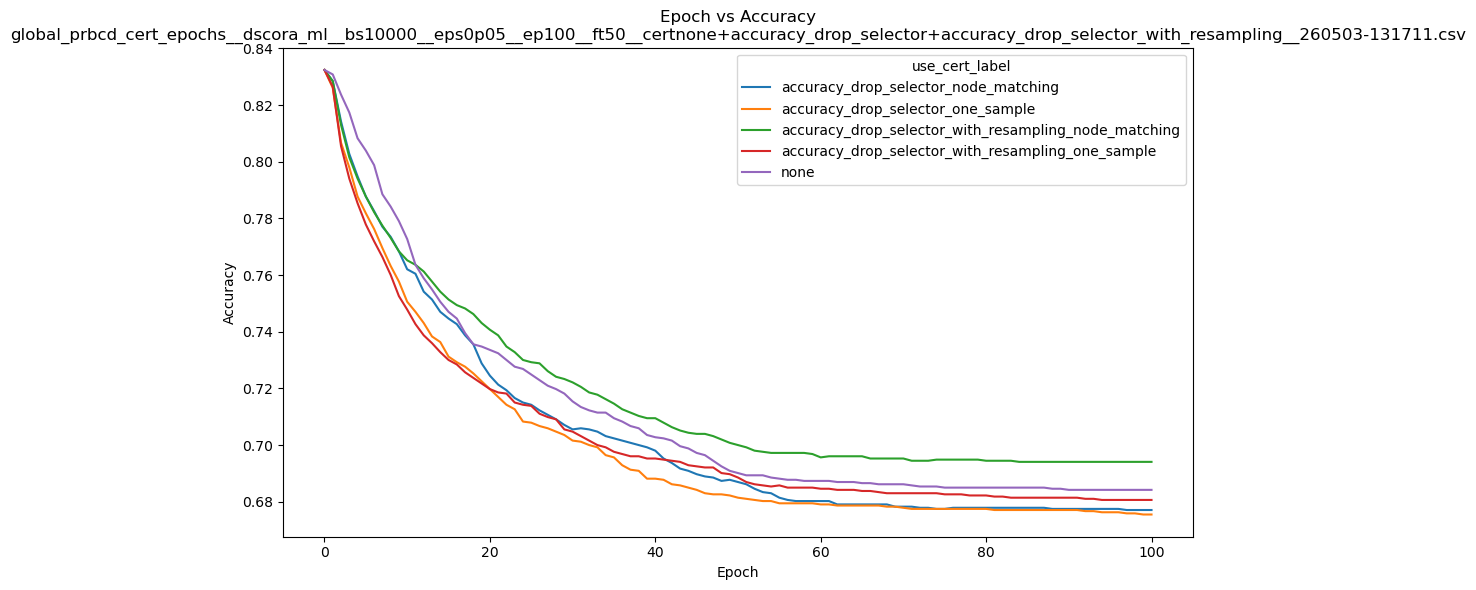

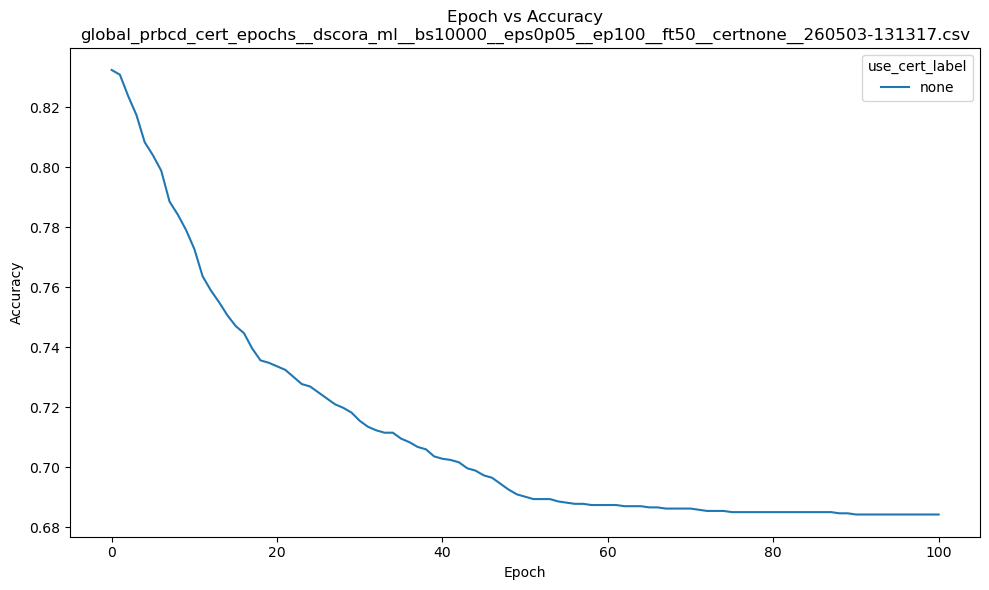

In [18]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Folder containing CSVs
csv_folder = "Plotting_Data"

# Collect relevant CSVs
csv_files = [
    os.path.join(csv_folder, f)
    for f in os.listdir(csv_folder)
    if f.endswith(".csv") and "global_prbcd_cert_epochs" in f
]

if not csv_files:
    raise FileNotFoundError("No matching CSV files found in Plotting_Data/")

# Candidates for column names
epoch_candidates = ["epoch_idx", "epoch", "Epoch", "step"]
acc_candidates = ["accuracy", "acc", "Accuracy"]

# New CSVs use use_cert_label; old CSVs may use use_cert
group_candidates = ["use_cert_label", "use_cert", "attack__use_cert"]

for csv_path in csv_files:
    df = pd.read_csv(csv_path)

    # Figure out epoch, accuracy, and grouping columns
    epoch_col = next((c for c in epoch_candidates if c in df.columns), None)
    acc_col = next((c for c in acc_candidates if c in df.columns), None)
    group_col = next((c for c in group_candidates if c in df.columns), None)

    if epoch_col is None or acc_col is None:
        print(f"Skipping {csv_path} because no epoch/accuracy column was found.")
        continue

    # Cast to numeric
    df[epoch_col] = pd.to_numeric(df[epoch_col], errors="coerce")
    df[acc_col] = pd.to_numeric(df[acc_col], errors="coerce")
    df = df.dropna(subset=[epoch_col, acc_col])

    plt.figure(figsize=(10, 6))

    if group_col is not None:
        for method, g in df.groupby(group_col, dropna=False):
            method = str(method)

            # Optional exclusions
            if method == "accuracy_drop_selector_k_hop":
                continue

            series = (
                g.groupby(epoch_col)[acc_col]
                .mean()
                .sort_index()
            )

            plt.plot(
                series.index.values,
                series.values,
                label=method,
            )

        plt.legend(title=group_col)

    else:
        series = (
            df.groupby(epoch_col)[acc_col]
            .mean()
            .sort_index()
        )

        plt.plot(series.index.values, series.values)

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"Epoch vs Accuracy\n{os.path.basename(csv_path)}")
    plt.tight_layout()
    plt.show()

### Plot Gradient vs Accuracy

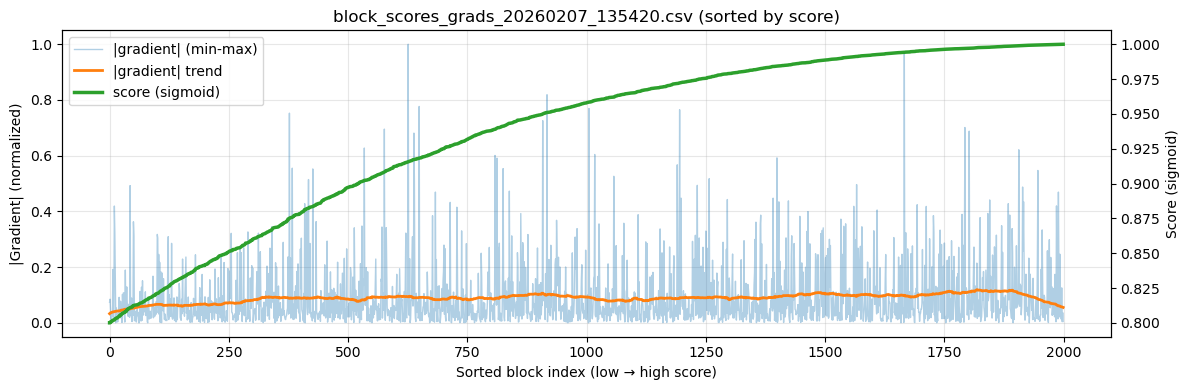

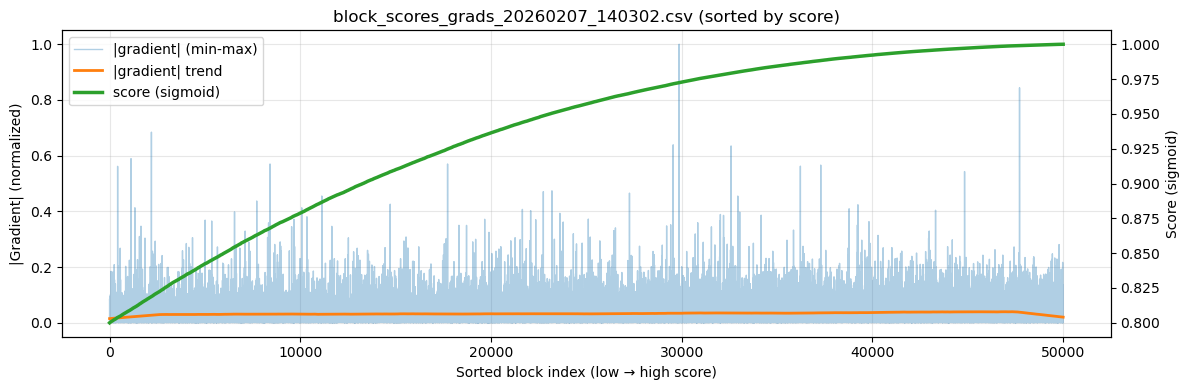

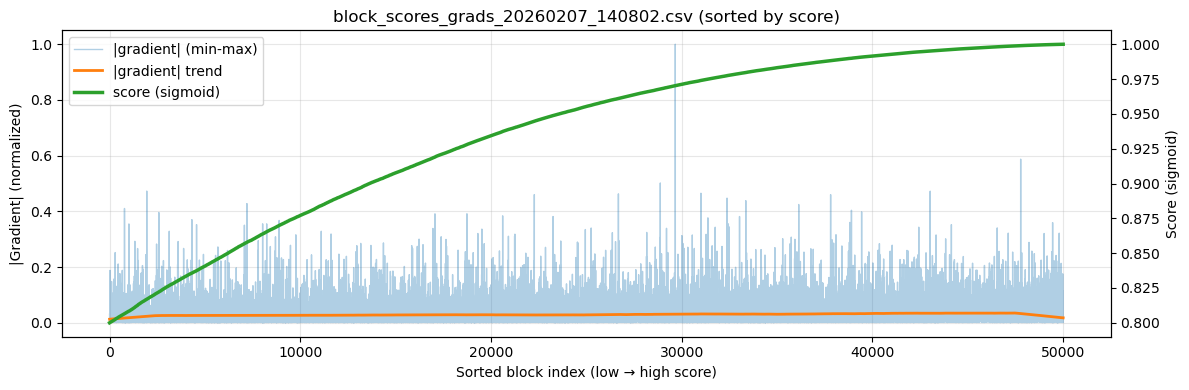

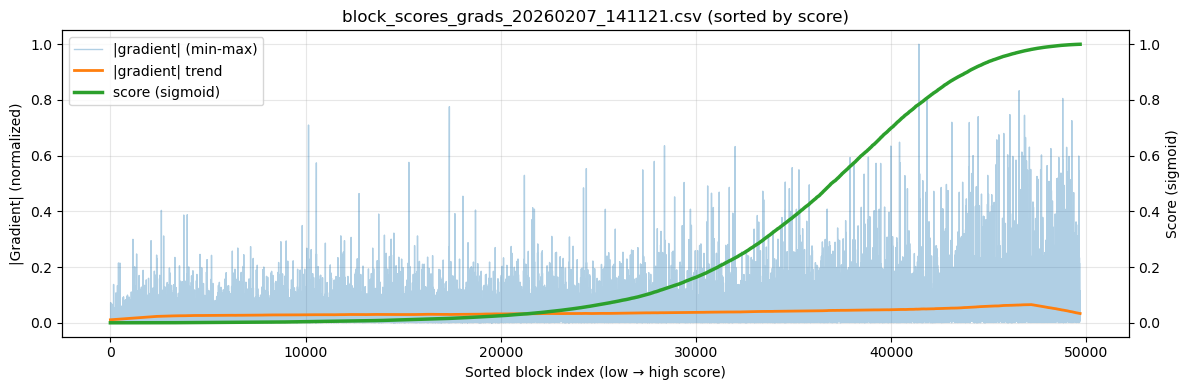

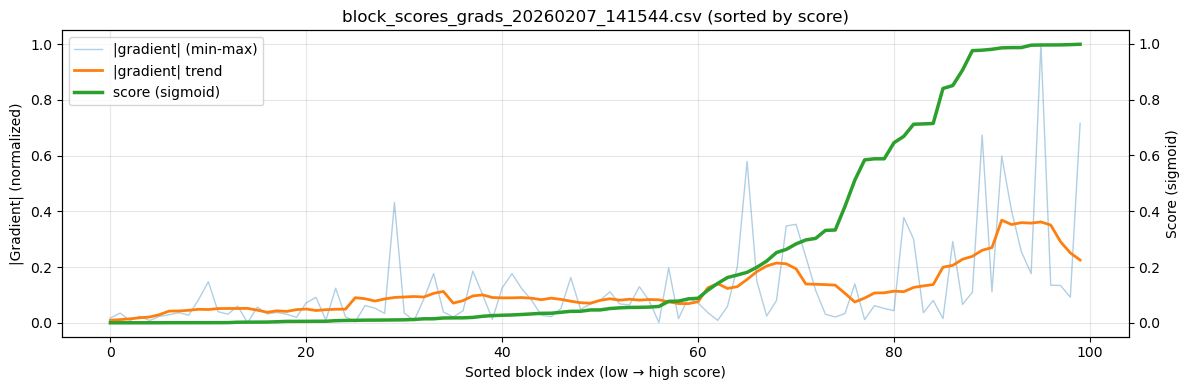

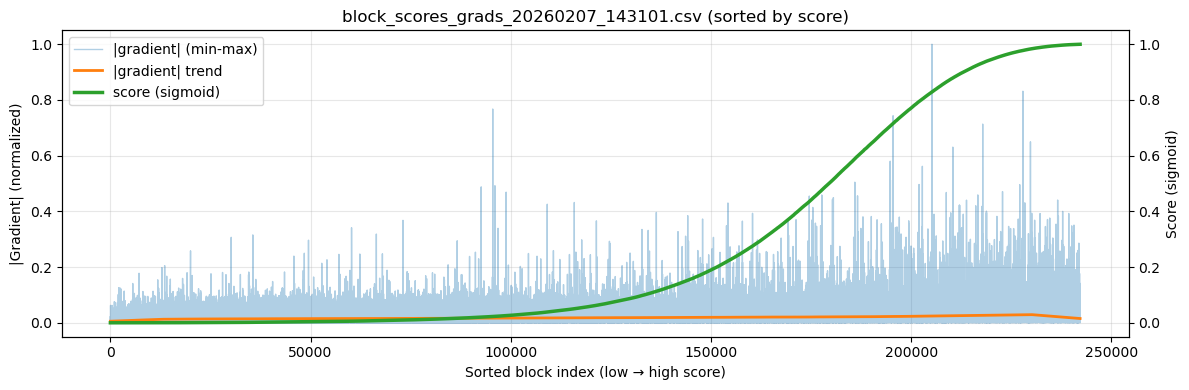

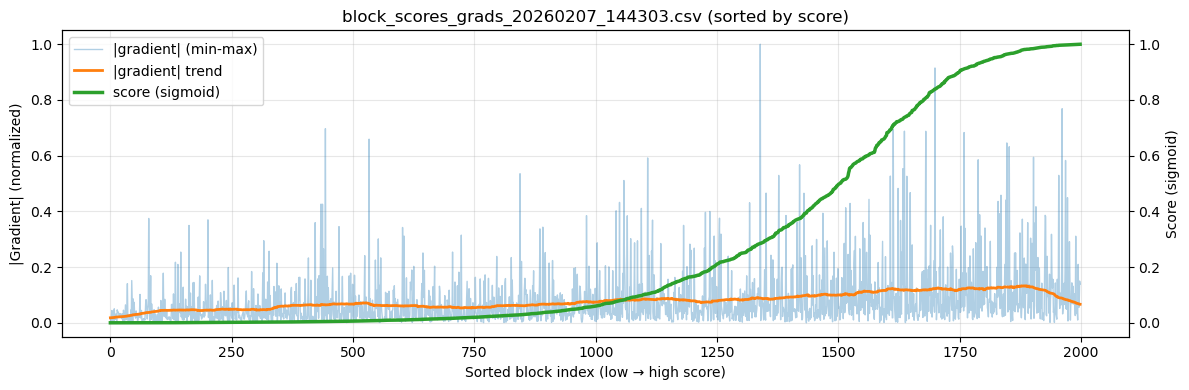

In [39]:
import os, csv
import numpy as np
import matplotlib.pyplot as plt

# --- CONFIG ---
csv_dir = "extendedPlotting/gradVsScores/selector"
window_frac = 0.1   # 10% of block size for moving average
# ----------------

assert os.path.isdir(csv_dir), f"Directory not found: {csv_dir}"
csv_files = sorted(f for f in os.listdir(csv_dir) if f.endswith(".csv"))
assert csv_files, "No CSV files found."

for fname in csv_files:
    path = os.path.join(csv_dir, fname)

    score, abs_grad = [], []
    with open(path, "r") as f:
        r = csv.DictReader(f)
        for row in r:
            score.append(float(row["score"]))
            abs_grad.append(float(row["abs_grad"]))

    score = np.asarray(score)      # already sigmoid in [0,1]
    abs_grad = np.asarray(abs_grad)

    # --- sort by score (ascending) ---
    order = np.argsort(score)
    score = score[order]
    abs_grad = abs_grad[order]

    # --- normalize gradient only ---
    def minmax(x):
        x_min, x_max = float(np.min(x)), float(np.max(x))
        if x_max - x_min < 1e-12:
            return np.zeros_like(x)
        return (x - x_min) / (x_max - x_min)

    grad_n = minmax(abs_grad)

    # --- gradient trendline ---
    n = len(grad_n)
    window = max(5, int(window_frac * n))
    kernel = np.ones(window) / window
    grad_trend = np.convolve(grad_n, kernel, mode="same")

    # --- plot ---
    fig, ax_grad = plt.subplots(figsize=(12, 4))

    # gradient (background)
    ax_grad.plot(
        grad_n,
        label="|gradient| (min-max)",
        alpha=0.35,
        linewidth=1,
        color="tab:blue",
    )
    ax_grad.plot(
        grad_trend,
        label="|gradient| trend",
        linewidth=2,
        color="tab:orange",
    )
    ax_grad.set_ylabel("|Gradient| (normalized)")

    # score (foreground, second axis)
    ax_score = ax_grad.twinx()
    ax_score.plot(
        score,
        label="score (sigmoid)",
        linewidth=2.5,
        color="tab:green",
    )
    ax_score.set_ylabel("Score (sigmoid)")

    ax_grad.set_xlabel("Sorted block index (low → high score)")
    plt.title(f"{fname} (sorted by score)")

    # combined legend
    lines1, labels1 = ax_grad.get_legend_handles_labels()
    lines2, labels2 = ax_score.get_legend_handles_labels()
    ax_grad.legend(
        lines1 + lines2,
        labels1 + labels2,
        loc="upper left",
    )

    ax_grad.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()

### Plot Accuracy Rejection Curve

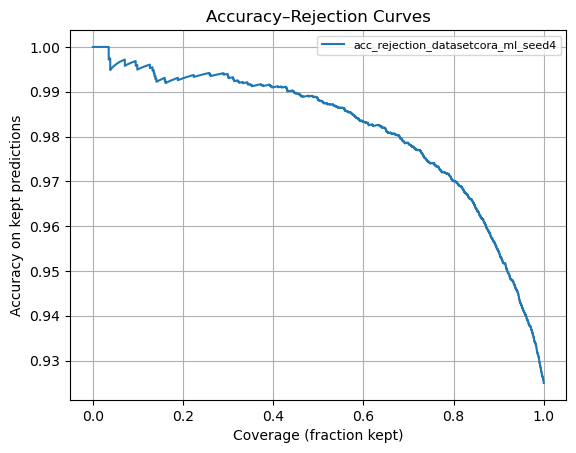

In [31]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

dir_path = "extendedPlotting/accuracyRejection"
csv_files = sorted(glob.glob(os.path.join(dir_path, "*.csv")))

if not csv_files:
    raise FileNotFoundError(f"No CSV files found in: {dir_path}")

plt.figure()
for fp in csv_files:
    df = pd.read_csv(fp)

    # Basic validation
    required_cols = {"confidence", "correct"}
    if not required_cols.issubset(df.columns):
        raise ValueError(f"{os.path.basename(fp)} missing columns {required_cols - set(df.columns)}")

    # Drop NaNs just in case
    df = df.dropna(subset=["confidence", "correct"])

    # Sort by confidence descending (reject low-confidence first)
    df = df.sort_values("confidence", ascending=False)

    correct = df["correct"].astype(float).to_numpy()
    cum_correct = np.cumsum(correct)
    k = np.arange(1, len(correct) + 1, dtype=float)

    accuracy = cum_correct / k
    coverage = k / float(len(correct))

    label = os.path.splitext(os.path.basename(fp))[0]
    plt.plot(coverage, accuracy, label=label)

plt.xlabel("Coverage (fraction kept)")
plt.ylabel("Accuracy on kept predictions")
plt.title("Accuracy–Rejection Curves")
plt.grid(True)
plt.legend(fontsize=8, loc="best")
plt.show()

### Plot Spearman Rho vs Blocksize

C:\Users\Schulz\AppData\Local\Temp\ipykernel_16448\1773011565.py:17: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat(df_list, ignore_index=True)


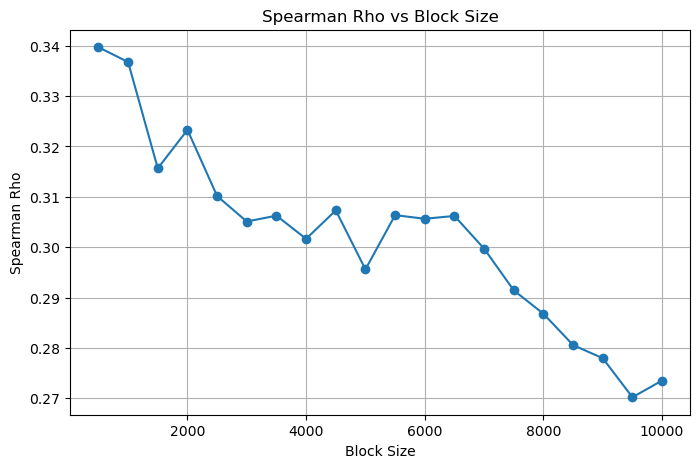

In [24]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Load all result CSVs
# =========================
RESULTS_DIR = os.path.join("extendedPlotting", "spearmanRho")

csv_files = glob.glob(os.path.join(RESULTS_DIR, "global_prbcd_cert_results__*.csv"))

if not csv_files:
    raise FileNotFoundError(f"No result CSVs found in {RESULTS_DIR}")

df_list = [pd.read_csv(f) for f in csv_files]
df = pd.concat(df_list, ignore_index=True)

# Ensure numeric
df["block_size"] = pd.to_numeric(df["block_size"], errors="coerce")
df["spearman_rho"] = pd.to_numeric(df["spearman_rho"], errors="coerce")

# Drop rows with missing values
df = df.dropna(subset=["block_size", "spearman_rho"])

# =========================
# Aggregate (mean over runs)
# =========================
agg = (
    df.groupby("block_size")["spearman_rho"]
    .mean()
    .reset_index()
    .sort_values("block_size")
)

# =========================
# Plot
# =========================
plt.figure(figsize=(8, 5))
plt.plot(agg["block_size"], agg["spearman_rho"], marker="o")
plt.xlabel("Block Size")
plt.ylabel("Spearman Rho")
plt.title("Spearman Rho vs Block Size")
plt.grid(True)
plt.show()

In [18]:
from helpers import csvHelper

csvHelper.average_csvs_over_seed(
    folder="./Plotting_Data/SeedAvg",
    output_folder="./Plotting_Data/SeedAvg/Averaged"
)

[skip] global_prbcd_cert_epochs_seed1_dscora_mlbs2000+50000__eps0p01+0p025+0p05+0p1__ep50__ft25__certaccuracy_drop_selector+none__260129-124140_eps_0.05_block_size_2000.csv: no 'seed' column
[ok] global_prbcd_cert_epochs_seed4_dscora_mlbs2000+50000__eps0p01+0p025+0p05+0p1__ep100__ft25__certaccuracy_drop_selector+none__260203-100255_block_size_2000_eps_0.05.csv → global_prbcd_cert_epochs_seed4_dscora_mlbs2000+50000__eps0p01+0p025+0p05+0p1__ep100__ft25__certaccuracy_drop_selector+none__260203-100255_block_size_2000_eps_0.05_avg.csv


In [36]:
import pandas as pd
from pathlib import Path

# directories
input_dir = Path("./split_csv")
output_dir = input_dir / "split_by_eps"
output_dir.mkdir(parents=True, exist_ok=True)

# process all csv files except those already in /split_by_eps
for csv_file in input_dir.glob("*.csv"):
    print(f"Processing {csv_file.name}")

    df = pd.read_csv(csv_file)

    if "epsilon" not in df.columns:
        print(f"  Skipped (no 'epsilon' column)")
        continue

    for eps, df_eps in df.groupby("epsilon"):
        out_name = f"{csv_file.stem}_eps_{eps}.csv"
        out_path = output_dir / out_name

        df_eps.to_csv(out_path, index=False)
        print(f"  → wrote {out_path} ({len(df_eps)} rows)")

Processing global_prbcd_cert_epochs__dscora_mlbs2000__eps0p01+0p025+0p05+0p1__ep100__ft25__certaccuracy_drop_selector+none__260208-161930.csv
  → wrote split_csv\split_by_eps\global_prbcd_cert_epochs__dscora_mlbs2000__eps0p01+0p025+0p05+0p1__ep100__ft25__certaccuracy_drop_selector+none__260208-161930_eps_0.01.csv (303 rows)
  → wrote split_csv\split_by_eps\global_prbcd_cert_epochs__dscora_mlbs2000__eps0p01+0p025+0p05+0p1__ep100__ft25__certaccuracy_drop_selector+none__260208-161930_eps_0.025.csv (303 rows)
  → wrote split_csv\split_by_eps\global_prbcd_cert_epochs__dscora_mlbs2000__eps0p01+0p025+0p05+0p1__ep100__ft25__certaccuracy_drop_selector+none__260208-161930_eps_0.05.csv (303 rows)
  → wrote split_csv\split_by_eps\global_prbcd_cert_epochs__dscora_mlbs2000__eps0p01+0p025+0p05+0p1__ep100__ft25__certaccuracy_drop_selector+none__260208-161930_eps_0.1.csv (303 rows)


In [18]:
import pandas as pd
from pathlib import Path

# directories
input_dir = Path("./split_csv")
output_dir = input_dir / "split_by_bs"
output_dir.mkdir(parents=True, exist_ok=True)

# process all csv files except those already in /done
for csv_file in input_dir.glob("*.csv"):
    print(f"Processing {csv_file.name}")

    df = pd.read_csv(csv_file)

    if "block_size" not in df.columns:
        print(f"  Skipped (no 'block_size' column)")
        continue

    for block_size, df_bs in df.groupby("block_size"):
        out_name = f"{csv_file.stem}_block_size_{block_size}.csv"
        out_path = output_dir / out_name

        df_bs.to_csv(out_path, index=False)
        print(f"  → wrote {out_path} ({len(df_bs)} rows)")


Processing global_prbcd_cert_epochs__dscora_mlbs2000+50000__eps0p01+0p025+0p05+0p1__ep100__ft25__certaccuracy_drop_selector+none__260207-150100_eps_0.01.csv
  → wrote split_csv\split_by_bs\global_prbcd_cert_epochs__dscora_mlbs2000+50000__eps0p01+0p025+0p05+0p1__ep100__ft25__certaccuracy_drop_selector+none__260207-150100_eps_0.01_block_size_2000.csv (303 rows)
  → wrote split_csv\split_by_bs\global_prbcd_cert_epochs__dscora_mlbs2000+50000__eps0p01+0p025+0p05+0p1__ep100__ft25__certaccuracy_drop_selector+none__260207-150100_eps_0.01_block_size_50000.csv (303 rows)
Processing global_prbcd_cert_epochs__dscora_mlbs2000+50000__eps0p01+0p025+0p05+0p1__ep100__ft25__certaccuracy_drop_selector+none__260207-150100_eps_0.025.csv
  → wrote split_csv\split_by_bs\global_prbcd_cert_epochs__dscora_mlbs2000+50000__eps0p01+0p025+0p05+0p1__ep100__ft25__certaccuracy_drop_selector+none__260207-150100_eps_0.025_block_size_2000.csv (303 rows)
  → wrote split_csv\split_by_bs\global_prbcd_cert_epochs__dscora_mlb

### 2.2.1 Global PR-BCD Attack without Cert

Now let's do the same with a non-local `PR-BCD` attack. For this, we use [experiments/experiment_global_attack_direct.py](https://github.com/sigeisler/robustness_of_gnns_at_scale/blob/main/experiments/experiment_global_attack_direct.py#L63).

In [ ]:
from DeleteCache import delete_pert_files_and_folders

delete_pert_files_and_folders(
    cache_dir="cache",
    pert_adj_storage_type="evasion_global_adj",
    pert_attr_storage_type="evasion_global_attr"
)

global_prbcd_statistics = experiment_global_attack_direct.run(
    data_dir = './data',
    dataset = 'cora_ml',
    attack = 'PRBCD',
    attack_params = dict(
        epochs=50,
        fine_tune_epochs=100,
        keep_heuristic="WeightOnly",
        search_space_size=100_000,
        block_size=2000,
        do_synchronize=True,
        loss_type="tanhMargin",
    ),
    epsilons = [0.25],
    binary_attr = False,
    make_undirected = True,
    seed=0,
    artifact_dir = 'cache',
    pert_adj_storage_type = 'evasion_global_adj',
    pert_attr_storage_type = 'evasion_global_attr',
    model_label = 'Vanilla GCN',
    model_storage_type = 'demo',
    #device = 0,
    #data_device = 0,
    device = "cpu",
    data_device = "cpu",
    debug_level = "info",
)

print(global_prbcd_statistics)

In [ ]:
perturbed_acc_cert = global_prbcd_statistics_cert["results"][0]['accuracy']
print(f'Clean accuracy: {100*clean_acc:.2f}%; Accuracy after global PRBCD attack with cert: {100*perturbed_acc_cert:.2f}%')

In [ ]:
perturbed_acc = global_prbcd_statistics["results"][0]['accuracy']
print(f'Clean accuracy: {100*clean_acc:.2f}%; Accuracy after global PRBCD attack: {100*perturbed_acc:.2f}%')

In [ ]:

# Plot
plt.figure(figsize=(12, 8))
sns.lineplot(
    data=df_filtered,
    x="epoch",
    y="accuracy",
    hue="use_cert",
    style="use_cert",
    markers=True,
    dashes=False,
    estimator="mean"
)
